# Polymer Informatics Atlas

## Notebook 02 — Polymer Representations and Feature Engineering

### Objective

Notebook 01 established the integrity, chemical diversity, target structure, and interpretable chemical space of the polymer dataset.

The present notebook investigates how polymer repeat-unit chemistry should be represented for machine-learning applications.

Polymer informatics differs from conventional small-molecule cheminformatics because polymer SMILES contain wildcard atoms (`*`) that encode continuation of the macromolecular chain. These connection points are chemically meaningful features of the repeat-unit representation but are not ordinary atoms.

This notebook therefore develops and compares multiple representation families rather than assuming that a single representation is universally optimal.

The objectives are to:

1. recover and verify the curated dataset produced in Notebook 01,
2. distinguish polymer-specific representation issues from conventional molecular representation,
3. construct interpretable descriptor and fingerprint feature spaces,
4. evaluate the effect of polymer connection-point handling,
5. examine fingerprint sparsity and structural similarity,
6. identify redundant, invariant, or problematic features,
7. create reproducible feature matrices for downstream modelling,
8. and determine which representations should be compared in Notebook 03.

No property-prediction model is selected in advance. Representation quality will later be assessed through controlled predictive and generalization experiments.

## 1. Environment and Reproducibility

This notebook uses the curated dataset exported from Notebook 01 rather than reconstructing the entire data-audit workflow.

The principal libraries are:

- **pandas** for tabular data manipulation,
- **NumPy** for numerical operations,
- **RDKit** for molecular graph parsing, fingerprints, descriptors, and chemical similarity,
- **scikit-learn** for preprocessing and dimensional analysis,
- **matplotlib** for visualization.

A fixed random seed is used wherever stochastic operations are introduced so that downstream analyses remain reproducible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Core environment initialized.")

Core environment initialized.


In [ ]:
!pip -q install rdkit

In [ ]:
from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import AllChem, Descriptors

print("RDKit version:", rdBase.rdkitVersion)

RDKit version: 2026.03.6


## 2. Recovering the Curated Polymer Dataset

Notebook 02 begins from the curated output of Notebook 01.

The curated table contains:

- original polymer SMILES,
- canonicalized polymer structures,
- target-property values,
- polymer connection-point metadata,
- elemental and functional-group descriptors,
- and PCA chemical-space coordinates.

The dataset is revalidated after loading to ensure that file transfer between notebooks has not altered its structure or target coverage.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving polymer_atlas_curated.csv to polymer_atlas_curated (1).csv


In [ ]:
atlas = pd.read_csv(
    "polymer_atlas_curated.csv"
)

print("Curated dataset loaded.")
print(f"Rows:    {atlas.shape[0]:,}")
print(f"Columns: {atlas.shape[1]}")

display(atlas.head())

Curated dataset loaded.
Rows:    7,973
Columns: 62


,id,SMILES,canonical_smiles,architecture_class,n_connection_points,connection_bond_types,n_fragments,n_targets_available,target_signature,Tg,...,PC1_domain,PC2_domain,PC3_domain,PC4_domain,PC5_domain,PC6_domain,PC7_domain,PC8_domain,PC9_domain,PC10_domain
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,*CC(*)c1ccccc1C(=O)OCCCCCC,two_connection_points,2,"('SINGLE', 'SINGLE')",1,2,FFV + Tc,NaN,...,-0.649197,-0.501616,-1.530676,-0.377044,-0.921553,-0.789689,-0.654967,-0.519208,-0.151527,0.062819
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,two_connection_points,2,"('SINGLE', 'SINGLE')",1,1,FFV,NaN,...,2.058174,0.516462,-0.570184,-0.124404,-0.458523,-0.285411,-0.241132,-0.036293,0.081060,0.372666
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,two_connection_points,2,"('SINGLE', 'SINGLE')",1,1,FFV,NaN,...,1.447896,0.028326,0.179972,-2.547085,2.378282,-0.508372,1.605745,0.689843,-1.485056,-0.987873
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,two_connection_points,2,"('SINGLE', 'SINGLE')",1,1,FFV,NaN,...,2.698342,0.489948,-0.226389,-0.328117,-0.404317,-0.210368,-0.453630,-0.347343,-0.094485,0.188064
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,two_connection_points,2,"('SINGLE', 'SINGLE')",1,1,FFV,NaN,...,-0.047239,-0.409306,0.484767,-1.402313,0.006284,0.966344,0.649818,0.269031,0.718589,0.008530


In [ ]:
target_columns = [
    "Tg",
    "FFV",
    "Tc",
    "Density",
    "Rg"
]

print("NOTEBOOK 02 ENTRY AUDIT")
print("=" * 65)

print(f"Total polymers:          {len(atlas):,}")
print(f"Unique IDs:              {atlas['id'].nunique():,}")
print(f"Unique SMILES:           {atlas['SMILES'].nunique():,}")
print(
    f"Unique canonical SMILES: "
    f"{atlas['canonical_smiles'].nunique():,}"
)

print("\nTARGET COUNTS")
print("-" * 65)

for target in target_columns:
    print(
        f"{target:8s}: "
        f"{atlas[target].notna().sum():,}"
    )

NOTEBOOK 02 ENTRY AUDIT
Total polymers:          7,973
Unique IDs:              7,973
Unique SMILES:           7,973
Unique canonical SMILES: 7,973

TARGET COUNTS
-----------------------------------------------------------------
Tg      : 511
FFV     : 7,030
Tc      : 737
Density : 613
Rg      : 614


## 3. Polymer Boundary Representation

Polymer SMILES contain wildcard atoms (`*`) that mark positions where the represented repeat unit connects to neighbouring repeat units in the macromolecular chain.

These wildcard atoms create an important representation problem.

For conventional molecular machine learning, several approaches are possible:

1. **retain the wildcard atoms**, preserving the original polymer repeat-unit representation;
2. **remove the wildcard atoms and allow the remaining structure to satisfy normal valence**, producing a finite molecular fragment;
3. **replace the wildcard atoms with explicit terminal atoms**, such as hydrogen.

These approaches are not chemically equivalent.

In particular, direct hydrogen replacement is problematic when a wildcard is connected through a double bond because hydrogen cannot preserve an arbitrary double bond to the boundary atom.

Notebook 01 identified a small population containing double-bonded connection points. Therefore, no universal hydrogen-capping rule is assumed.

The present section constructs and audits a connection-point-removed representation while retaining the original polymer SMILES as the primary structural record. The transformed representation is treated as a modelling representation rather than as the chemically exact polymer itself.

In [ ]:
def get_boundary_bond_types(smiles):
    mol = Chem.MolFromSmiles(smiles)

    bond_types = []

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 0:
            for bond in atom.GetBonds():
                bond_types.append(
                    str(bond.GetBondType())
                )

    return tuple(sorted(bond_types))


atlas["boundary_bond_types_recomputed"] = (
    atlas["SMILES"].apply(
        get_boundary_bond_types
    )
)

boundary_patterns = (
    atlas["boundary_bond_types_recomputed"]
    .value_counts()
)

print("RECOMPUTED POLYMER-BOUNDARY BOND PATTERNS")
print("=" * 70)

display(
    boundary_patterns
    .rename("Number of polymers")
    .to_frame()
)

RECOMPUTED POLYMER-BOUNDARY BOND PATTERNS


,Number of polymers
boundary_bond_types_recomputed,
"(SINGLE, SINGLE)",7940
"(DOUBLE, DOUBLE)",15
"(SINGLE, SINGLE, SINGLE)",8
"(SINGLE, SINGLE, SINGLE, SINGLE, SINGLE)",5
"(SINGLE, SINGLE, SINGLE, SINGLE)",3
"(SINGLE,)",2


In [ ]:
def all_boundary_bonds_single(smiles):
    mol = Chem.MolFromSmiles(smiles)

    boundary_bonds = []

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 0:
            for bond in atom.GetBonds():
                boundary_bonds.append(
                    bond.GetBondType()
                )

    return all(
        bond == Chem.BondType.SINGLE
        for bond in boundary_bonds
    )


atlas["all_boundary_bonds_single"] = (
    atlas["SMILES"].apply(
        all_boundary_bonds_single
    )
)

print("BOUNDARY-BOND SAFETY AUDIT")
print("=" * 70)

display(
    atlas["all_boundary_bonds_single"]
    .value_counts()
    .rename("Number of polymers")
    .to_frame()
)

BOUNDARY-BOND SAFETY AUDIT


,Number of polymers
all_boundary_bonds_single,
True,7958
False,15


### 3.2 Connection-Point-Removed Repeat-Unit Representation

A finite representation is generated by removing wildcard atoms from the molecular graph and re-sanitizing the remaining structure with RDKit.

For ordinary single-bonded connection points, sanitization typically permits the boundary atoms to satisfy their normal valence through implicit hydrogen.

However, this operation must not be interpreted as reconstructing the real macromolecule. It removes information about polymerization connectivity and may alter the apparent terminal valence of repeat units with non-single connection bonds.

The transformed structure is therefore referred to as the **valence-completed repeat-unit core** rather than the polymer itself.

In [ ]:
def make_valence_completed_core(smiles):
    """
    Remove polymer wildcard atoms (*) and sanitize the
    remaining molecular graph.

    Returns
    -------
    core_smiles : str or None
        Canonical SMILES of the transformed finite fragment.

    valid : bool
        Whether RDKit successfully sanitized the transformed graph.
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series({
            "core_smiles": None,
            "core_valid": False
        })

    try:
        editable = Chem.RWMol(mol)

        dummy_indices = [
            atom.GetIdx()
            for atom in editable.GetAtoms()
            if atom.GetAtomicNum() == 0
        ]

        # Remove from highest index to lowest so that
        # earlier atom indices are not shifted prematurely.
        for idx in sorted(
            dummy_indices,
            reverse=True
        ):
            editable.RemoveAtom(idx)

        core = editable.GetMol()

        Chem.SanitizeMol(core)

        core_smiles = Chem.MolToSmiles(
            core,
            canonical=True,
            isomericSmiles=True
        )

        return pd.Series({
            "core_smiles": core_smiles,
            "core_valid": True
        })

    except Exception:
        return pd.Series({
            "core_smiles": None,
            "core_valid": False
        })


core_results = atlas["SMILES"].apply(
    make_valence_completed_core
)

atlas = pd.concat(
    [atlas, core_results],
    axis=1
)

print(
    "Valence-completed repeat-unit cores generated."
)

[06:36:01] Can't kekulize mol.  Unkekulized atoms: 13 14 15 18 21 22 24
[06:36:01] Can't kekulize mol.  Unkekulized atoms: 13 14 15 18 21 22 24
[06:36:03] Can't kekulize mol.  Unkekulized atoms: 15 16 17 20 23 24 25
[06:36:03] Can't kekulize mol.  Unkekulized atoms: 15 16 17 20 23 24 25
[06:36:04] Can't kekulize mol.  Unkekulized atoms: 25 26 27 30 33 34 35
[06:36:04] Can't kekulize mol.  Unkekulized atoms: 25 26 27 30 33 34 35
[06:36:04] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 20 21 22
[06:36:04] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 20 21 22
[06:36:04] Can't kekulize mol.  Unkekulized atoms: 17 18 19 22 25 26 27
[06:36:04] Can't kekulize mol.  Unkekulized atoms: 17 18 19 22 25 26 27
[06:36:06] Can't kekulize mol.  Unkekulized atoms: 15 16 17 20 23 24 25
[06:36:06] Can't kekulize mol.  Unkekulized atoms: 15 16 17 20 23 24 25
[06:36:06] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 20 21 22
[06:36:06] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 2

Valence-completed repeat-unit cores generated.


In [ ]:
print("VALENCE-COMPLETED CORE VALIDATION")
print("=" * 70)

print(
    f"Valid transformed cores: "
    f"{atlas['core_valid'].sum():,} / {len(atlas):,}"
)

print(
    f"Invalid transformed cores: "
    f"{(~atlas['core_valid']).sum():,}"
)

print(
    f"Unique transformed cores: "
    f"{atlas.loc[atlas['core_valid'], 'core_smiles'].nunique():,}"
)

VALENCE-COMPLETED CORE VALIDATION
Valid transformed cores: 7,956 / 7,973
Invalid transformed cores: 17
Unique transformed cores: 7,849


### 3.3 Representation Collisions

Removing polymer connection points may cause originally distinct polymer representations to collapse onto the same finite molecular core.

Such collisions are important because the location and nature of polymerization boundaries can distinguish polymer structures even when their remaining finite fragments appear identical.

The number and identity of these collisions are therefore quantified before the transformed representation is used for fingerprints or modelling.

In [ ]:
valid_core = atlas.loc[
    atlas["core_valid"]
].copy()

core_counts = (
    valid_core["core_smiles"]
    .value_counts()
)

collision_cores = core_counts[
    core_counts > 1
]

n_collision_cores = len(
    collision_cores
)

n_records_in_collisions = (
    valid_core[
        valid_core["core_smiles"].isin(
            collision_cores.index
        )
    ]
    .shape[0]
)

print("CORE REPRESENTATION COLLISION AUDIT")
print("=" * 70)

print(
    f"Unique core structures involved in collisions: "
    f"{n_collision_cores:,}"
)

print(
    f"Polymer records involved in collisions: "
    f"{n_records_in_collisions:,}"
)

print(
    f"Total unique core structures: "
    f"{valid_core['core_smiles'].nunique():,}"
)

CORE REPRESENTATION COLLISION AUDIT
Unique core structures involved in collisions: 98
Polymer records involved in collisions: 205
Total unique core structures: 7,849


In [ ]:
if n_collision_cores > 0:

    collision_records = (
        valid_core[
            valid_core["core_smiles"].isin(
                collision_cores.index
            )
        ]
        [
            [
                "id",
                "SMILES",
                "core_smiles",
                "architecture_class",
                "boundary_bond_types_recomputed",
                "Tg",
                "FFV",
                "Tc",
                "Density",
                "Rg"
            ]
        ]
        .sort_values(
            "core_smiles"
        )
    )

    display(
        collision_records.head(50)
    )

else:
    print(
        "No core-representation collisions detected."
    )

,id,SMILES,core_smiles,architecture_class,boundary_bond_types_recomputed,Tg,FFV,Tc,Density,Rg
5887,1596743017,*C=C*,C=C,two_connection_points,"(SINGLE, SINGLE)",NaN,0.425737,NaN,NaN,NaN
3407,933916766,*/C=C/*,C=C,two_connection_points,"(SINGLE, SINGLE)",59.558838,NaN,0.394000,0.775000,34.672906
7697,2074481050,*C=CC(C)C(*)C,C=CC(C)CC,two_connection_points,"(SINGLE, SINGLE)",78.178805,NaN,NaN,NaN,NaN
2655,722656060,*/C=C/C(C)C(*)C,C=CC(C)CC,two_connection_points,"(SINGLE, SINGLE)",NaN,NaN,NaN,0.801255,16.530776
2746,748600767,*/C=C/C1CCC(*)C1,C=CC1CCCC1,two_connection_points,"(SINGLE, SINGLE)",NaN,NaN,0.260333,NaN,NaN
5959,1617425937,*C=CC1CCC(*)C1,C=CC1CCCC1,two_connection_points,"(SINGLE, SINGLE)",NaN,0.388866,NaN,NaN,NaN
2624,713020314,*C=CCC*,C=CCC,two_connection_points,"(SINGLE, SINGLE)",NaN,0.418661,NaN,NaN,NaN
6047,1639915624,*/C=C/CC*,C=CCC,two_connection_points,"(SINGLE, SINGLE)",NaN,NaN,0.248667,0.841158,19.293411
506,140415340,*C=CCCC*,C=CCCC,two_connection_points,"(SINGLE, SINGLE)",NaN,0.413696,NaN,NaN,NaN
6243,1693536620,*/C=C/CCC*,C=CCCC,two_connection_points,"(SINGLE, SINGLE)",NaN,NaN,0.266550,0.834589,18.186019


In [ ]:
comparison_columns = [
    "id",
    "SMILES",
    "core_smiles",
    "boundary_bond_types_recomputed",
    "all_boundary_bonds_single",
    "architecture_class"
]

print("EXAMPLE REPRESENTATION TRANSFORMATIONS")
print("=" * 70)

display(
    atlas[
        comparison_columns
    ].sample(
        15,
        random_state=RANDOM_STATE
    )
)

EXAMPLE REPRESENTATION TRANSFORMATIONS


,id,SMILES,core_smiles,boundary_bond_types_recomputed,all_boundary_bonds_single,architecture_class
7560,2042618640,*C=Cc1ccc2c3ccc(*)cc3n(-c3ccc(OCCCCCCCCCC)c(OC...,C=Cc1ccc2c3ccccc3n(-c3ccc(OCCCCCCCCCC)c(OCCCCC...,"(SINGLE, SINGLE)",True,two_connection_points
1405,377905218,*CC(=O)NCCCCCCNC(=O)Cc1ccc(O*)cc1,CC(=O)NCCCCCCNC(=O)Cc1ccc(O)cc1,"(SINGLE, SINGLE)",True,two_connection_points
5196,1409584413,*CC(*)c1ccccc1C(=O)NC,CCc1ccccc1C(=O)NC,"(SINGLE, SINGLE)",True,two_connection_points
2087,562022603,*c1ccc2c(c1)C(=O)N(c1ccc(Oc3ccc(N4C(=O)c5ccc(-...,O=C1c2ccccc2C(=O)N1c1ccc(Oc2ccc(N3C(=O)c4ccc(-...,"(SINGLE, SINGLE)",True,two_connection_points
3337,914466551,*CC(*)OC(=O)c1ccc(-c2ccccc2)cc1,CCOC(=O)c1ccc(-c2ccccc2)cc1,"(SINGLE, SINGLE)",True,two_connection_points
1302,351987442,*c1ccc(C(=O)Nc2cccc(S(=O)(=O)c3cccc(NC(=O)c4cc...,O=C(Nc1cccc(S(=O)(=O)c2cccc(NC(=O)c3ccc(N4C(=O...,"(SINGLE, SINGLE)",True,two_connection_points
5030,1365694834,*CCCCCCCC(=O)OCC1COC(*)O1,CCCCCCCC(=O)OCC1COCO1,"(SINGLE, SINGLE)",True,two_connection_points
737,206145001,*c1ccc(Oc2ccc(N3C(=O)c4ccc(Oc5ccc(C(=O)c6ccc(O...,O=C(c1ccc(Oc2ccc3c(c2)C(=O)NC3=O)cc1)c1ccc(Oc2...,"(SINGLE, SINGLE)",True,two_connection_points
7528,2035543497,*CCCCNC(=O)c1cccc(C(=O)N*)c1,CCCCNC(=O)c1cccc(C(N)=O)c1,"(SINGLE, SINGLE)",True,two_connection_points
7391,1998309406,*c1ccc(N2C(=O)c3ccc(C(=O)c4ccc5c(c4)C(=O)N(c4c...,O=C(c1ccc2c(c1)C(=O)N(c1ccccc1)C2=O)c1ccc2c(c1...,"(SINGLE, SINGLE)",True,two_connection_points


In [ ]:
non_single_boundary = atlas.loc[
    ~atlas["all_boundary_bonds_single"],
    comparison_columns
].copy()

print("NON-SINGLE POLYMER-BOUNDARY REPRESENTATIONS")
print("=" * 70)

print(
    f"Number of polymers: "
    f"{len(non_single_boundary):,}"
)

display(
    non_single_boundary
)

NON-SINGLE POLYMER-BOUNDARY REPRESENTATIONS
Number of polymers: 15


,id,SMILES,core_smiles,boundary_bond_types_recomputed,all_boundary_bonds_single,architecture_class
173,52181246,*=C=C=C(COS(=O)(=O)c1ccc(OC)cc1)C(=*)COS(=O)(=...,C=C=C(CCOS(=O)(=O)c1ccc(OC)cc1)COS(=O)(=O)c1cc...,"(DOUBLE, DOUBLE)",False,two_connection_points
842,234538951,*=Nc1cccc(Oc2cccc(Oc3cccc(N=C4OC(=O)c5cc6c(cc5...,Nc1cccc(Oc2cccc(Oc3cccc(N=C4OC(=O)c5cc6c(cc54)...,"(DOUBLE, DOUBLE)",False,two_connection_points
1027,281517661,*=C=C=C(Cn1c2ccccc2c2ccccc21)C(=*)Cn1c2ccccc2c...,C=C=C(CCn1c2ccccc2c2ccccc21)Cn1c2ccccc2c2ccccc21,"(DOUBLE, DOUBLE)",False,two_connection_points
1070,289972048,*=Cc1ccc(C=C2SC(=S)N(c3ccc(N4C(=O)C(=*)SC4=S)c...,Cc1ccc(C=C2SC(=S)N(c3ccc(N4C(=O)CSC4=S)cc3)C2=...,"(DOUBLE, DOUBLE)",False,two_connection_points
1345,364021169,*=C=C=C(COS(=O)(=O)c1ccc(C)cc1)C(=*)COS(=O)(=O...,C=C=C(CCOS(=O)(=O)c1ccc(C)cc1)COS(=O)(=O)c1ccc...,"(DOUBLE, DOUBLE)",False,two_connection_points
1520,407820973,*=C=C=C(CO)C(=*)CO,C=C=C(CO)CCO,"(DOUBLE, DOUBLE)",False,two_connection_points
2244,608511939,*=Cc1ccc(C(=O)CCCCC(=O)c2ccc(C=C3CN(C)CC(=*)C3...,Cc1ccc(C(=O)CCCCC(=O)c2ccc(C=C3CN(C)CCC3=O)o2)o1,"(DOUBLE, DOUBLE)",False,two_connection_points
3707,1004048009,*=C=C=C(CCCCOC(=O)NC(=O)OCCCC)C(=*)CCCCOC(=O)N...,C=C=C(CCCCCOC(=O)NC(=O)OCCCC)CCCCOC(=O)NC(=O)O...,"(DOUBLE, DOUBLE)",False,two_connection_points
4783,1293239198,*=c1cc2ccc3cc(=c4c5ccccc5c(=*)c5ccccc45)cc4ccc...,None,"(DOUBLE, DOUBLE)",False,two_connection_points
5704,1547263064,*=CC#C[Si](C#CC=NN=*)(c1ccccc1)c1ccccc1,CC#C[Si](C#CC=NN)(c1ccccc1)c1ccccc1,"(DOUBLE, DOUBLE)",False,two_connection_points


### 3.4 Transformation Failures and Representation Information Loss

Removing polymer connection points does not preserve all polymer representations uniquely.

Of the original polymer structures, a small number cannot be converted into sanitized finite cores after wildcard removal. These failures arise from the transformation itself rather than from invalid original polymer SMILES.

Furthermore, multiple distinct polymer representations may collapse onto the same valence-completed finite core. Such representation collisions indicate loss of information concerning polymerization boundaries or repeat-unit connectivity.

Before transformed cores are used for machine-learning representations, both transformation failures and collisions are examined explicitly.

In [ ]:
# ============================================================
# Audit failed core transformations
# ============================================================

invalid_core_columns = [
    "id",
    "SMILES",
    "architecture_class",
    "n_connection_points",
    "boundary_bond_types_recomputed",
    "all_boundary_bonds_single",
    "Tg",
    "FFV",
    "Tc",
    "Density",
    "Rg"
]

invalid_cores = atlas.loc[
    ~atlas["core_valid"],
    invalid_core_columns
].copy()

print("FAILED CORE TRANSFORMATIONS")
print("=" * 75)

print(
    f"Number of failed transformations: "
    f"{len(invalid_cores):,}"
)

display(invalid_cores)

FAILED CORE TRANSFORMATIONS
Number of failed transformations: 17


,id,SMILES,architecture_class,n_connection_points,boundary_bond_types_recomputed,all_boundary_bonds_single,Tg,FFV,Tc,Density,Rg
177,53248904,*CCCCCCCCCCn1c(=O)c2cc3c(=O)n(*)c(=O)c3c(Br)c2...,two_connection_points,2,"(SINGLE, SINGLE)",True,137.108726,NaN,NaN,NaN,NaN
979,267912832,*CCCCCCCCCCCCn1c(=O)c2cc3c(=O)n(*)c(=O)c3cc2c1=O,two_connection_points,2,"(SINGLE, SINGLE)",True,73.376396,NaN,NaN,NaN,NaN
1642,441800426,*CCCCCC(=O)Oc1ccc2cc(OC(=O)CCCCCn3c(=O)c4cc5c(...,two_connection_points,2,"(SINGLE, SINGLE)",True,-10.304144,NaN,NaN,NaN,NaN
1751,471964961,*c1ccc(Cc2ccc(-n3c(=O)c4cc5c(=O)n(*)c(=O)c5cc4...,two_connection_points,2,"(SINGLE, SINGLE)",True,NaN,NaN,NaN,1.232934,29.700866
1775,478096853,*CC(=O)OCCCCCCOC(=O)Cn1c(=O)c2cc3c(=O)n(*)c(=O...,two_connection_points,2,"(SINGLE, SINGLE)",True,55.498647,NaN,NaN,NaN,NaN
3187,865948061,*c1ccc(-c2ccc(-c3ccc(-n4c(=O)c5cc6c(=O)n(*)c(=...,two_connection_points,2,"(SINGLE, SINGLE)",True,278.522178,NaN,NaN,NaN,NaN
3631,985685560,*c1ccc(-c2nc3cc(-n4c(=O)c5cc6c(=O)n(*)c(=O)c6c...,two_connection_points,2,"(SINGLE, SINGLE)",True,456.350000,NaN,NaN,NaN,NaN
3871,1050100593,*c1ccc(C(=O)Nc2ccc(NC(=O)c3ccc(-n4c(=O)c5sc6c(...,two_connection_points,2,"(SINGLE, SINGLE)",True,327.244199,NaN,NaN,NaN,NaN
4044,1092542084,*c1ccc(-n2c(=O)c3c(F)c4c(=O)n(*)c(=O)c4c(F)c3c...,two_connection_points,2,"(SINGLE, SINGLE)",True,337.816724,NaN,NaN,NaN,NaN
4783,1293239198,*=c1cc2ccc3cc(=c4c5ccccc5c(=*)c5ccccc45)cc4ccc...,two_connection_points,2,"(DOUBLE, DOUBLE)",False,437.490000,NaN,NaN,NaN,NaN


In [ ]:
print("FAILED TRANSFORMATIONS BY BOUNDARY TYPE")
print("=" * 75)

display(
    invalid_cores[
        "boundary_bond_types_recomputed"
    ]
    .value_counts()
    .rename("Number of failed cores")
    .to_frame()
)

print("\nFAILED TRANSFORMATIONS BY ARCHITECTURE")
print("=" * 75)

display(
    invalid_cores[
        "architecture_class"
    ]
    .value_counts()
    .rename("Number of failed cores")
    .to_frame()
)

print("\nSINGLE-BOUNDARY STATUS")
print("=" * 75)

display(
    invalid_cores[
        "all_boundary_bonds_single"
    ]
    .value_counts()
    .rename("Number of failed cores")
    .to_frame()
)

FAILED TRANSFORMATIONS BY BOUNDARY TYPE


,Number of failed cores
boundary_bond_types_recomputed,
"(SINGLE, SINGLE)",15
"(DOUBLE, DOUBLE)",2



FAILED TRANSFORMATIONS BY ARCHITECTURE


,Number of failed cores
architecture_class,
two_connection_points,17



SINGLE-BOUNDARY STATUS


,Number of failed cores
all_boundary_bonds_single,
True,15
False,2


### 3.5 Core-Representation Collisions

A representation collision occurs when two or more distinct polymer SMILES become identical after polymer connection points are removed.

Collisions are scientifically important because they demonstrate that the finite-core transformation is many-to-one: information present in the polymer representation can be erased by the transformation.

The size and property composition of each collision group are therefore examined before the finite-core representation is used downstream.

In [ ]:
# ============================================================
# Reconstruct all collision groups
# ============================================================

collision_records = valid_core.loc[
    valid_core["core_smiles"].isin(
        collision_cores.index
    )
].copy()

collision_group_sizes = (
    collision_records
    .groupby("core_smiles")
    .size()
    .sort_values(ascending=False)
)

print("CORE COLLISION GROUP SIZES")
print("=" * 75)

print(
    f"Collision groups: "
    f"{len(collision_group_sizes):,}"
)

print(
    f"Records involved: "
    f"{len(collision_records):,}"
)

print(
    f"Largest collision group: "
    f"{collision_group_sizes.max():,} polymers"
)

display(
    collision_group_sizes
    .rename("Number of original polymer records")
    .to_frame()
)

CORE COLLISION GROUP SIZES
Collision groups: 98
Records involved: 205
Largest collision group: 3 polymers


,Number of original polymer records
core_smiles,
CCC(C)C,3
C=Cc1ccccc1,3
CCC1CCCC1,3
CCc1ccccc1,3
c1ccc(-c2cnc3ccc(Oc4ccc5nc(-c6ccccc6)c(-c6ccccc6)nc5c4)cc3n2)cc1,3
...,...
c1ccc(-c2nc3ccccc3o2)cc1,2
c1ccc(Oc2ccc(-c3cnc4ccc(-c5ccc6nccnc6c5)cc4n3)cc2)cc1,2
c1ccc(Oc2ccc(Oc3ccc(-c4cnc5ccc(-c6ccc7nccnc7c6)cc5n4)cc3)cc2)cc1,2


In [ ]:
# ============================================================
# Property information within collision groups
# ============================================================

collision_target_rows = []

for core_smiles, group in collision_records.groupby(
    "core_smiles"
):

    row = {
        "core_smiles": core_smiles,
        "n_original_polymers": len(group)
    }

    for target in target_columns:

        values = group[target].dropna()

        row[f"{target}_n_measurements"] = len(values)
        row[f"{target}_n_unique_values"] = values.nunique()

        if len(values) >= 2:
            row[f"{target}_range"] = (
                values.max() - values.min()
            )
        else:
            row[f"{target}_range"] = np.nan

    collision_target_rows.append(row)


collision_target_audit = pd.DataFrame(
    collision_target_rows
)

display(
    collision_target_audit.head(20)
)

,core_smiles,n_original_polymers,Tg_n_measurements,Tg_n_unique_values,Tg_range,FFV_n_measurements,FFV_n_unique_values,FFV_range,Tc_n_measurements,Tc_n_unique_values,Tc_range,Density_n_measurements,Density_n_unique_values,Density_range,Rg_n_measurements,Rg_n_unique_values,Rg_range
0,C=C,2,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN
1,C=CC(C)CC,2,1,1,NaN,0,0,NaN,0,0,NaN,1,1,NaN,1,1,NaN
2,C=CC1CCCC1,2,0,0,NaN,1,1,NaN,1,1,NaN,0,0,NaN,0,0,NaN
3,C=CCC,2,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN
4,C=CCCC,2,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN
5,C=CCCCCCC,2,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN
6,C=CCCCCCCC(Cl)CCCCCC,2,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN
7,C=CCCCCCCCC,2,1,1,NaN,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN
8,C=CCCCCCCCCCC,2,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN
9,C=CCCCCCCCCCC(CCCCCCCCC)COCCOCCOCCOCCOCCCCCC,2,0,0,NaN,1,1,NaN,1,1,NaN,1,1,NaN,1,1,NaN


In [ ]:
print("TARGET INFORMATION WITHIN COLLISION GROUPS")
print("=" * 75)

for target in target_columns:

    multiple_measurements = (
        collision_target_audit[
            f"{target}_n_measurements"
        ] >= 2
    ).sum()

    multiple_values = (
        collision_target_audit[
            f"{target}_n_unique_values"
        ] >= 2
    ).sum()

    print(
        f"{target:8s} | "
        f"groups with >=2 measurements: "
        f"{multiple_measurements:2d} | "
        f"groups with >=2 distinct values: "
        f"{multiple_values:2d}"
    )

TARGET INFORMATION WITHIN COLLISION GROUPS
Tg       | groups with >=2 measurements:  1 | groups with >=2 distinct values:  1
FFV      | groups with >=2 measurements: 47 | groups with >=2 distinct values: 47
Tc       | groups with >=2 measurements: 12 | groups with >=2 distinct values: 12
Density  | groups with >=2 measurements:  9 | groups with >=2 distinct values:  9
Rg       | groups with >=2 measurements:  9 | groups with >=2 distinct values:  9


## 4. Polymer-Graph Morgan Fingerprints

The preceding representation audit demonstrated that removal of polymer connection points is not information-neutral.

Seventeen polymer representations could not be converted into sanitized finite cores, while 98 distinct finite-core collision groups caused 285 original polymer records to collapse onto shared transformed structures. Several collision groups also contained distinct values for the same target property.

Consequently, the original wildcard-containing polymer graph is retained as the primary fingerprint representation.

Morgan fingerprints are used to encode local atomic environments around each atom in the polymer repeat-unit graph. Unlike the interpretable descriptors developed in Notebook 01, Morgan fingerprints provide a high-dimensional representation capable of distinguishing detailed local substructures.

The initial fingerprint configuration uses:

- radius = 2,
- 2048 fingerprint bits,
- chirality information retained,
- and the original polymer wildcard atoms preserved.

This representation is treated as a baseline rather than assumed to be optimal. Fingerprint dimensionality, sparsity, uniqueness, and representation collisions are audited before predictive modelling.

In [ ]:
from rdkit.Chem import rdFingerprintGenerator

# ============================================================
# Morgan fingerprint configuration
# ============================================================

MORGAN_RADIUS = 2
MORGAN_BITS = 2048

morgan_generator = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=MORGAN_RADIUS,
        fpSize=MORGAN_BITS,
        includeChirality=True
    )
)

print("MORGAN FINGERPRINT CONFIGURATION")
print("=" * 70)

print(f"Radius:              {MORGAN_RADIUS}")
print(f"Fingerprint size:    {MORGAN_BITS} bits")
print("Chirality included: True")
print("Polymer wildcards:   retained")

MORGAN FINGERPRINT CONFIGURATION
Radius:              2
Fingerprint size:    2048 bits
Chirality included: True
Polymer wildcards:   retained


In [ ]:
def make_morgan_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return morgan_generator.GetFingerprint(mol)


raw_morgan_fps = atlas["SMILES"].apply(
    make_morgan_fingerprint
)

n_valid_raw_fps = raw_morgan_fps.notna().sum()

print("RAW POLYMER MORGAN FINGERPRINTS")
print("=" * 70)

print(
    f"Successfully generated: "
    f"{n_valid_raw_fps:,} / {len(atlas):,}"
)

print(
    f"Failures: "
    f"{raw_morgan_fps.isna().sum():,}"
)

RAW POLYMER MORGAN FINGERPRINTS
Successfully generated: 7,973 / 7,973
Failures: 0


In [ ]:
# ============================================================
# Convert RDKit bit vectors into NumPy matrix
# ============================================================

raw_fp_matrix = np.zeros(
    (len(atlas), MORGAN_BITS),
    dtype=np.uint8
)

for i, fp in enumerate(raw_morgan_fps):

    if fp is not None:
        DataStructs.ConvertToNumpyArray(
            fp,
            raw_fp_matrix[i]
        )

print("MORGAN FEATURE MATRIX")
print("=" * 70)

print(
    f"Shape: {raw_fp_matrix.shape}"
)

print(
    f"Data type: {raw_fp_matrix.dtype}"
)

print(
    f"Approximate memory: "
    f"{raw_fp_matrix.nbytes / (1024**2):.2f} MB"
)

MORGAN FEATURE MATRIX
Shape: (7973, 2048)
Data type: uint8
Approximate memory: 15.57 MB


### 4.1 Fingerprint Sparsity

Morgan fingerprints are expected to be sparse because an individual polymer repeat unit contains only a small fraction of all possible hashed structural environments.

Fingerprint sparsity affects memory use, model selection, similarity calculations, and interpretation.

The number and fraction of active fingerprint bits are therefore quantified for every polymer.

In [ ]:
raw_on_bits = raw_fp_matrix.sum(axis=1)

raw_fp_density = (
    raw_on_bits / MORGAN_BITS * 100
)

fingerprint_sparsity_summary = pd.DataFrame({
    "active_bits": raw_on_bits,
    "density_percent": raw_fp_density
})

print("RAW POLYMER FINGERPRINT SPARSITY")
print("=" * 70)

display(
    fingerprint_sparsity_summary
    .describe()
    .T
    .round(3)
)

RAW POLYMER FINGERPRINT SPARSITY


,count,mean,std,min,25%,50%,75%,max
active_bits,7973.0,37.954,13.014,4.000,28.000,37.000,46.000,117.000
density_percent,7973.0,1.853,0.635,0.195,1.367,1.807,2.246,5.713


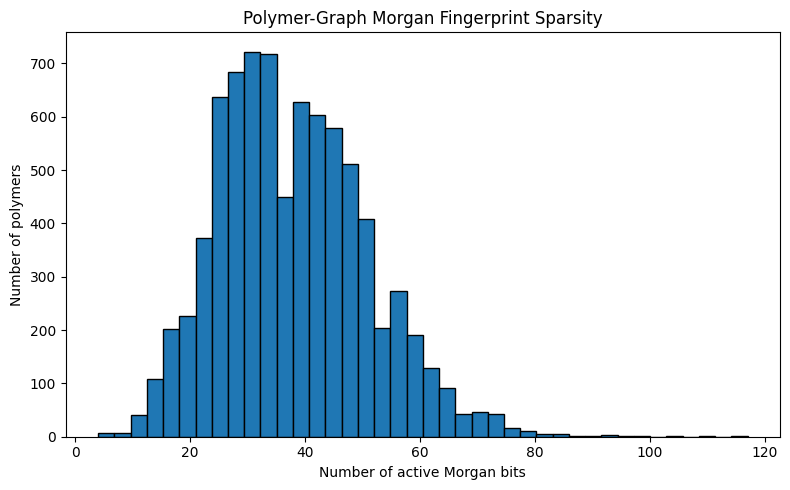

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    raw_on_bits,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Number of active Morgan bits")
plt.ylabel("Number of polymers")

plt.title(
    "Polymer-Graph Morgan Fingerprint Sparsity"
)

plt.tight_layout()
plt.show()

### 4.2 Fingerprint Uniqueness and Representation Collisions

A fingerprint is a compressed representation rather than a lossless molecular encoding.

Different polymer graphs may therefore produce identical Morgan fingerprint vectors because:

- the fingerprint contains only local environments up to a finite radius,
- distinct global arrangements may share the same local environments,
- and hashing maps many possible structural environments into a finite number of bits.

Fingerprint collisions are quantified before the representation is used for modelling.

In [ ]:
# Pack binary vectors into compact byte representations
# so identical fingerprints can be counted efficiently.

raw_fp_keys = [
    np.packbits(row).tobytes()
    for row in raw_fp_matrix
]

raw_fp_counts = (
    pd.Series(raw_fp_keys)
    .value_counts()
)

raw_fp_collision_groups = (
    raw_fp_counts[
        raw_fp_counts > 1
    ]
)

n_unique_raw_fps = len(
    raw_fp_counts
)

n_raw_fp_collision_groups = len(
    raw_fp_collision_groups
)

n_records_in_raw_fp_collisions = (
    raw_fp_collision_groups.sum()
)

print("RAW POLYMER FINGERPRINT UNIQUENESS")
print("=" * 70)

print(
    f"Original polymer structures: "
    f"{len(atlas):,}"
)

print(
    f"Unique Morgan fingerprints: "
    f"{n_unique_raw_fps:,}"
)

print(
    f"Fingerprint collision groups: "
    f"{n_raw_fp_collision_groups:,}"
)

print(
    f"Records involved in fingerprint collisions: "
    f"{n_records_in_raw_fp_collisions:,}"
)

if n_raw_fp_collision_groups > 0:
    print(
        f"Largest fingerprint collision group: "
        f"{raw_fp_collision_groups.max():,}"
    )

RAW POLYMER FINGERPRINT UNIQUENESS
Original polymer structures: 7,973
Unique Morgan fingerprints: 6,840
Fingerprint collision groups: 519
Records involved in fingerprint collisions: 1,652
Largest fingerprint collision group: 66


In [ ]:
bit_frequency = (
    raw_fp_matrix.sum(axis=0)
)

n_never_used = (
    bit_frequency == 0
).sum()

n_used = (
    bit_frequency > 0
).sum()

n_always_on = (
    bit_frequency == len(atlas)
).sum()

print("FINGERPRINT BIT UTILIZATION")
print("=" * 70)

print(
    f"Total fingerprint bits: "
    f"{MORGAN_BITS:,}"
)

print(
    f"Bits used by at least one polymer: "
    f"{n_used:,}"
)

print(
    f"Never-used bits: "
    f"{n_never_used:,}"
)

print(
    f"Bits active for every polymer: "
    f"{n_always_on:,}"
)

print(
    f"Feature-space utilization: "
    f"{100*n_used/MORGAN_BITS:.2f}%"
)

FINGERPRINT BIT UTILIZATION
Total fingerprint bits: 2,048
Bits used by at least one polymer: 2,048
Never-used bits: 0
Bits active for every polymer: 1
Feature-space utilization: 100.00%


### 4.3 Diagnosing Morgan Fingerprint Collisions

The radius-2, 2048-bit polymer-graph Morgan representation successfully encoded every polymer structure but produced fewer unique fingerprints than unique canonical polymer graphs.

This does not necessarily represent a hashing error. Binary Morgan fingerprints encode the presence of local atomic environments rather than complete molecular identity. Structurally distinct polymers may therefore share the same fingerprint when they contain equivalent sets of local environments, particularly when repeat units differ primarily in motif multiplicity or longer-range topology.

The largest collision groups are examined to determine whether information loss is primarily associated with repeat-unit size, repeated motifs, global topology, or fingerprint compression.

In [ ]:
atlas["raw_morgan_key"] = raw_fp_keys

raw_collision_counts = (
    atlas["raw_morgan_key"]
    .value_counts()
)

atlas["raw_morgan_group_size"] = (
    atlas["raw_morgan_key"]
    .map(raw_collision_counts)
)

print("MORGAN COLLISION GROUP SIZE DISTRIBUTION")
print("=" * 70)

display(
    atlas.loc[
        atlas["raw_morgan_group_size"] > 1,
        "raw_morgan_group_size"
    ]
    .value_counts()
    .sort_index()
    .rename("Number of polymers")
    .to_frame()
)

MORGAN COLLISION GROUP SIZE DISTRIBUTION


,Number of polymers
raw_morgan_group_size,
2,610
3,291
4,176
5,110
6,84
7,126
8,64
9,18
10,10


In [ ]:
largest_fp_key = (
    raw_collision_counts
    .idxmax()
)

largest_fp_group = atlas.loc[
    atlas["raw_morgan_key"] == largest_fp_key
].copy()

largest_fp_group = (
    largest_fp_group
    .sort_values("n_heavy_atoms")
)

print("LARGEST MORGAN FINGERPRINT COLLISION GROUP")
print("=" * 70)

print(
    f"Number of polymers: "
    f"{len(largest_fp_group):,}"
)

display(
    largest_fp_group[
        [
            "id",
            "SMILES",
            "n_heavy_atoms",
            "n_connection_points",
            "aromatic_fraction",
            "hetero_fraction",
            "Tg",
            "FFV",
            "Tc",
            "Density",
            "Rg"
        ]
    ]
)

LARGEST MORGAN FINGERPRINT COLLISION GROUP
Number of polymers: 66


,id,SMILES,n_heavy_atoms,n_connection_points,aromatic_fraction,hetero_fraction,Tg,FFV,Tc,Density,Rg
31,6645418,*CCCCCNC(=O)CCCCC(=O)N*,15,2,0.0,0.266667,NaN,0.332741,0.327000,NaN,NaN
4218,1141104268,*CCCCNC(=O)CCCCCCC(=O)N*,16,2,0.0,0.250000,NaN,NaN,0.291500,1.002012,18.290050
7300,1971561670,*CCCCCCNC(=O)CCCCC(=O)N*,16,2,0.0,0.250000,NaN,0.339033,NaN,NaN,NaN
1831,494602606,*CCCCCCCNC(=O)CCCCC(=O)N*,17,2,0.0,0.235294,NaN,0.341014,0.323000,NaN,NaN
5509,1495657690,*CCCCCCNC(=O)CCCCCC(=O)N*,17,2,0.0,0.235294,NaN,0.341680,0.278000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4538,1221138931,*CCCCCCCCCCCCCCNC(=O)CCCCCCCCCCCCCCCCC(=O)N*,36,2,0.0,0.111111,NaN,0.385526,0.434143,0.886925,21.348465
4993,1353112393,*CCCCCCCCCCNC(=O)CCCCCCCCCCCCCCCCCCCCC(=O)N*,36,2,0.0,0.111111,NaN,NaN,0.388250,0.884435,21.193854
5102,1385421838,*CCCCCCCCCCCCNC(=O)CCCCCCCCCCCCCCCCCCCCC(=O)N*,38,2,0.0,0.105263,NaN,NaN,0.394429,0.881826,22.001945
7726,2082251214,*CCCCCCCCCCCCCCCCCCNC(=O)CCCCCCCCCCCCCCCCC(=O)N*,40,2,0.0,0.100000,NaN,0.384913,0.453333,0.880971,22.409516


In [ ]:
collision_size_audit = []

for fp_key, group in atlas.groupby(
    "raw_morgan_key"
):

    if len(group) <= 1:
        continue

    collision_size_audit.append({
        "group_size": len(group),

        "min_heavy_atoms":
            group["n_heavy_atoms"].min(),

        "max_heavy_atoms":
            group["n_heavy_atoms"].max(),

        "heavy_atom_range":
            (
                group["n_heavy_atoms"].max()
                - group["n_heavy_atoms"].min()
            ),

        "n_unique_heavy_atom_counts":
            group["n_heavy_atoms"].nunique()
    })


collision_size_audit = pd.DataFrame(
    collision_size_audit
)

print("STRUCTURAL-SIZE VARIATION WITHIN MORGAN COLLISIONS")
print("=" * 70)

display(
    collision_size_audit
    .describe()
    .T
    .round(3)
)

STRUCTURAL-SIZE VARIATION WITHIN MORGAN COLLISIONS


,count,mean,std,min,25%,50%,75%,max
group_size,519.0,3.183,3.438,2.0,2.0,2.0,3.0,66.0
min_heavy_atoms,519.0,33.501,16.782,6.0,21.0,31.0,42.0,116.0
max_heavy_atoms,519.0,40.723,17.984,9.0,27.0,38.0,51.0,120.0
heavy_atom_range,519.0,7.222,5.561,0.0,4.0,6.0,9.0,36.0
n_unique_heavy_atom_counts,519.0,2.906,2.000,1.0,2.0,2.0,3.0,23.0


In [ ]:
universal_bits = np.where(
    bit_frequency == len(atlas)
)[0]

print("UNIVERSAL MORGAN BITS")
print("=" * 70)

print(
    f"Universal bit indices: "
    f"{universal_bits.tolist()}"
)

UNIVERSAL MORGAN BITS
Universal bit indices: [226]


In [ ]:
universal_bit = int(
    universal_bits[0]
)

print(
    f"Universal bit selected: "
    f"{universal_bit}"
)

Universal bit selected: 226


In [ ]:
from rdkit.Chem import rdFingerprintGenerator

example_indices = [
    0,
    1,
    2,
    3,
    4
]

for idx in example_indices:

    mol = Chem.MolFromSmiles(
        atlas.loc[idx, "SMILES"]
    )

    additional_output = (
        rdFingerprintGenerator.AdditionalOutput()
    )

    additional_output.AllocateBitInfoMap()

    _ = morgan_generator.GetFingerprint(
        mol,
        additionalOutput=additional_output
    )

    bit_info = (
        additional_output
        .GetBitInfoMap()
    )

    environments = bit_info.get(
        universal_bit,
        ()
    )

    print(
        f"Polymer index {idx}: "
        f"{environments}"
    )

Polymer index 0: ((0, 0), (3, 0))
Polymer index 1: ((0, 0), (28, 0))
Polymer index 2: ((0, 0), (51, 0))
Polymer index 3: ((0, 0), (25, 0))
Polymer index 4: ((0, 0), (40, 0))


In [ ]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    atlas["n_heavy_atoms"],
    raw_on_bits
)

print("FINGERPRINT SIZE RELATIONSHIP")
print("=" * 70)

print(
    f"Spearman correlation between "
    f"heavy-atom count and active bits: "
    f"{rho:.3f}"
)

print(
    f"p-value: {p_value:.3e}"
)

FINGERPRINT SIZE RELATIONSHIP
Spearman correlation between heavy-atom count and active bits: 0.824
p-value: 0.000e+00


### 4.4 Universal Polymer-Boundary Fingerprint Feature

One Morgan fingerprint bit is active for every polymer in the dataset.

Because almost every polymer representation contains two wildcard connection-point atoms, the universal bit may correspond to the radius-zero atomic environment of the polymer wildcard (`*`).

The atom identities responsible for this bit are inspected directly before assigning a chemical interpretation.

In [ ]:
# ============================================================
# Identify atoms responsible for the universal Morgan bit
# ============================================================

for idx in [0, 1, 2, 3, 4]:

    smiles = atlas.loc[idx, "SMILES"]
    mol = Chem.MolFromSmiles(smiles)

    additional_output = (
        rdFingerprintGenerator.AdditionalOutput()
    )

    additional_output.AllocateBitInfoMap()

    _ = morgan_generator.GetFingerprint(
        mol,
        additionalOutput=additional_output
    )

    bit_info = (
        additional_output
        .GetBitInfoMap()
    )

    environments = bit_info.get(
        universal_bit,
        ()
    )

    print(f"\nPolymer index {idx}")
    print(f"SMILES: {smiles}")

    for atom_idx, radius in environments:

        atom = mol.GetAtomWithIdx(
            atom_idx
        )

        print(
            f"  atom index={atom_idx:3d} | "
            f"radius={radius} | "
            f"symbol={atom.GetSymbol():>2s} | "
            f"atomic number={atom.GetAtomicNum()}"
        )


Polymer index 0
SMILES: *CC(*)c1ccccc1C(=O)OCCCCCC
  atom index=  0 | radius=0 | symbol= * | atomic number=0
  atom index=  3 | radius=0 | symbol= * | atomic number=0

Polymer index 1
SMILES: *Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5ccc(N*)cc5)cc4)CCC(CCCCC)CC3)cc2)cc1
  atom index=  0 | radius=0 | symbol= * | atomic number=0
  atom index= 28 | radius=0 | symbol= * | atomic number=0

Polymer index 2
SMILES: *Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(S(=O)(=O)c7ccc(Oc8ccc(C=C9CCCC(=Cc%10ccc(*)cc%10)C9=O)cc8)cc7)cc6)cc5)CCCCC4)cc3)cc2)cc1
  atom index=  0 | radius=0 | symbol= * | atomic number=0
  atom index= 51 | radius=0 | symbol= * | atomic number=0

Polymer index 3
SMILES: *Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)c(-c3ccc(C)cc3)c2-c2ccc(C)cc2)cc1
  atom index=  0 | radius=0 | symbol= * | atomic number=0
  atom index= 25 | radius=0 | symbol= * | atomic number=0

Polymer index 4
SMILES: *Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N+](=O)[O-])cc3)c(C(*)=O)cc2OCCCCCCCCCOCC

## 5. Count-Based Morgan Fingerprints

Binary Morgan fingerprints encode whether a structural environment occurs but not how many times it occurs.

The collision analysis demonstrated that many distinct polymer repeat units, particularly homologous structures differing in motif repetition or chain length, collapse onto identical binary fingerprints.

This behaviour is especially relevant to polymer informatics because repeated chemical motifs are intrinsic to polymer structure.

A count-based Morgan representation is therefore constructed using the same radius and fingerprint dimensionality as the binary representation.

Keeping all other fingerprint parameters fixed allows the effect of **environment multiplicity** to be evaluated independently of fingerprint radius or feature-space size.

In [ ]:
# ============================================================
# Count Morgan fingerprints
# ============================================================

count_fp_matrix = np.zeros(
    (len(atlas), MORGAN_BITS),
    dtype=np.uint16
)

for i, smiles in enumerate(
    atlas["SMILES"]
):

    mol = Chem.MolFromSmiles(
        smiles
    )

    count_fp = (
        morgan_generator
        .GetCountFingerprint(mol)
    )

    DataStructs.ConvertToNumpyArray(
        count_fp,
        count_fp_matrix[i]
    )

print("COUNT MORGAN FEATURE MATRIX")
print("=" * 70)

print(
    f"Shape: {count_fp_matrix.shape}"
)

print(
    f"Data type: {count_fp_matrix.dtype}"
)

print(
    f"Maximum environment count: "
    f"{count_fp_matrix.max()}"
)

print(
    f"Approximate memory: "
    f"{count_fp_matrix.nbytes / (1024**2):.2f} MB"
)

COUNT MORGAN FEATURE MATRIX
Shape: (7973, 2048)
Data type: uint16
Maximum environment count: 64
Approximate memory: 31.14 MB


In [ ]:
example_idx = 0

binary_nonzero = np.where(
    raw_fp_matrix[example_idx] > 0
)[0]

count_nonzero = np.where(
    count_fp_matrix[example_idx] > 0
)[0]

print("BINARY VS COUNT REPRESENTATION")
print("=" * 70)

print(
    f"Polymer ID: "
    f"{atlas.loc[example_idx, 'id']}"
)

print(
    f"Binary active features: "
    f"{len(binary_nonzero)}"
)

print(
    f"Count non-zero features: "
    f"{len(count_nonzero)}"
)

print(
    f"Total counted environments: "
    f"{count_fp_matrix[example_idx].sum()}"
)

print(
    f"Maximum count in one feature: "
    f"{count_fp_matrix[example_idx].max()}"
)

BINARY VS COUNT REPRESENTATION
Polymer ID: 87817
Binary active features: 38
Count non-zero features: 38
Total counted environments: 53
Maximum count in one feature: 6


In [ ]:
# ============================================================
# Count-fingerprint uniqueness
# ============================================================

count_fp_keys = [
    row.tobytes()
    for row in count_fp_matrix
]

count_fp_counts = (
    pd.Series(count_fp_keys)
    .value_counts()
)

count_collision_groups = (
    count_fp_counts[
        count_fp_counts > 1
    ]
)

n_unique_count_fps = len(
    count_fp_counts
)

n_count_collision_groups = len(
    count_collision_groups
)

n_records_count_collisions = (
    count_collision_groups.sum()
)

print("COUNT MORGAN FINGERPRINT UNIQUENESS")
print("=" * 70)

print(
    f"Original polymer structures: "
    f"{len(atlas):,}"
)

print(
    f"Unique count fingerprints: "
    f"{n_unique_count_fps:,}"
)

print(
    f"Collision groups: "
    f"{n_count_collision_groups:,}"
)

print(
    f"Records involved in collisions: "
    f"{n_records_count_collisions:,}"
)

if n_count_collision_groups > 0:

    print(
        f"Largest collision group: "
        f"{count_collision_groups.max():,}"
    )

COUNT MORGAN FINGERPRINT UNIQUENESS
Original polymer structures: 7,973
Unique count fingerprints: 7,835
Collision groups: 103
Records involved in collisions: 241
Largest collision group: 7


In [ ]:
representation_comparison = pd.DataFrame({
    "Binary Morgan": [
        len(atlas),
        n_unique_raw_fps,
        n_raw_fp_collision_groups,
        n_records_in_raw_fp_collisions,
        raw_fp_collision_groups.max()
    ],

    "Count Morgan": [
        len(atlas),
        n_unique_count_fps,
        n_count_collision_groups,
        n_records_count_collisions,
        (
            count_collision_groups.max()
            if n_count_collision_groups > 0
            else 1
        )
    ]
},
index=[
    "Polymer records",
    "Unique fingerprints",
    "Collision groups",
    "Records in collisions",
    "Largest collision group"
])

print("BINARY VS COUNT MORGAN")
print("=" * 70)

display(
    representation_comparison
)

BINARY VS COUNT MORGAN


,Binary Morgan,Count Morgan
Polymer records,7973,7973
Unique fingerprints,6840,7835
Collision groups,519,103
Records in collisions,1652,241
Largest collision group,66,7


### 5.1 Residual Collisions in Count-Based Morgan Fingerprints

Count-based Morgan fingerprints substantially reduce representation collisions relative to binary fingerprints, demonstrating that motif multiplicity accounts for much of the information loss in the binary representation.

However, a small number of distinct polymer graphs remain indistinguishable at radius 2.

These residual collisions are examined before increasing fingerprint radius. If colliding polymers have comparable sizes but differ in longer-range arrangement, this would indicate a limitation of the local radius rather than missing motif-count information.

In [ ]:
# ============================================================
# Residual count-Morgan collision groups
# ============================================================

atlas["count_morgan_key_r2"] = count_fp_keys

count_group_sizes = (
    atlas["count_morgan_key_r2"]
    .value_counts()
)

atlas["count_morgan_group_size_r2"] = (
    atlas["count_morgan_key_r2"]
    .map(count_group_sizes)
)

print("COUNT-MORGAN COLLISION GROUP SIZE DISTRIBUTION")
print("=" * 70)

display(
    atlas.loc[
        atlas["count_morgan_group_size_r2"] > 1,
        "count_morgan_group_size_r2"
    ]
    .value_counts()
    .sort_index()
    .rename("Number of polymers")
    .to_frame()
)

COUNT-MORGAN COLLISION GROUP SIZE DISTRIBUTION


,Number of polymers
count_morgan_group_size_r2,
2,166
3,36
4,12
5,20
7,7


In [ ]:
largest_count_key = (
    count_group_sizes.idxmax()
)

largest_count_group = atlas.loc[
    atlas["count_morgan_key_r2"]
    == largest_count_key
].copy()

print("LARGEST COUNT-MORGAN COLLISION GROUP")
print("=" * 70)

print(
    f"Number of polymers: "
    f"{len(largest_count_group):,}"
)

display(
    largest_count_group[
        [
            "id",
            "SMILES",
            "n_heavy_atoms",
            "n_connection_points",
            "aromatic_fraction",
            "hetero_fraction",
            "Tg",
            "FFV",
            "Tc",
            "Density",
            "Rg"
        ]
    ]
)

LARGEST COUNT-MORGAN COLLISION GROUP
Number of polymers: 7


,id,SMILES,n_heavy_atoms,n_connection_points,aromatic_fraction,hetero_fraction,Tg,FFV,Tc,Density,Rg
1400,376977834,*CCCCCCCNC(=O)CCCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.4065,0.940665,22.707749
1702,458811601,*CCCCCCNC(=O)CCCCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,0.364030,NaN,NaN,NaN
2483,676068988,*CCCCCCCCNC(=O)CCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,0.356533,0.3920,NaN,NaN
4373,1178529764,*CCCCCCCCCCNC(=O)CCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.4220,0.946533,22.259833
4780,1291851819,*CCCCCCCCCCCCNC(=O)CCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.3745,0.944709,22.084253
6721,1822483719,*CCCCCNC(=O)CCCCCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.3545,0.943380,21.690941
7165,1933820661,*CCCCCCCCCNC(=O)CCCCCCCC(=O)N*,22,2,0.0,0.181818,9.904825,NaN,0.3610,0.944002,22.959970


In [ ]:
largest_count_key = (
    count_group_sizes.idxmax()
)

largest_count_group = atlas.loc[
    atlas["count_morgan_key_r2"]
    == largest_count_key
].copy()

print("LARGEST COUNT-MORGAN COLLISION GROUP")
print("=" * 70)

print(
    f"Number of polymers: "
    f"{len(largest_count_group):,}"
)

display(
    largest_count_group[
        [
            "id",
            "SMILES",
            "n_heavy_atoms",
            "n_connection_points",
            "aromatic_fraction",
            "hetero_fraction",
            "Tg",
            "FFV",
            "Tc",
            "Density",
            "Rg"
        ]
    ]
)

LARGEST COUNT-MORGAN COLLISION GROUP
Number of polymers: 7


,id,SMILES,n_heavy_atoms,n_connection_points,aromatic_fraction,hetero_fraction,Tg,FFV,Tc,Density,Rg
1400,376977834,*CCCCCCCNC(=O)CCCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.4065,0.940665,22.707749
1702,458811601,*CCCCCCNC(=O)CCCCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,0.364030,NaN,NaN,NaN
2483,676068988,*CCCCCCCCNC(=O)CCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,0.356533,0.3920,NaN,NaN
4373,1178529764,*CCCCCCCCCCNC(=O)CCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.4220,0.946533,22.259833
4780,1291851819,*CCCCCCCCCCCCNC(=O)CCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.3745,0.944709,22.084253
6721,1822483719,*CCCCCNC(=O)CCCCCCCCCCCC(=O)N*,22,2,0.0,0.181818,NaN,NaN,0.3545,0.943380,21.690941
7165,1933820661,*CCCCCCCCCNC(=O)CCCCCCCC(=O)N*,22,2,0.0,0.181818,9.904825,NaN,0.3610,0.944002,22.959970


### 5.2 Effect of Fingerprint Radius on Residual Representation Collisions

Count-based Morgan fingerprints substantially reduced the information loss observed with binary fingerprints.

The remaining radius-2 collision groups differ less in repeat-unit size and instead contain structures with similar local chemical composition but different longer-range arrangements.

This suggests that some residual information loss may arise because a radius-2 fingerprint does not extend sufficiently far through the molecular graph to distinguish positional or topological differences.

To test this hypothesis, a radius-3 count Morgan representation is constructed while keeping fingerprint dimensionality, chirality handling, and polymer wildcard treatment unchanged.

This controlled comparison isolates the effect of increasing structural neighbourhood size.

In [ ]:
# ============================================================
# Radius-3 count Morgan fingerprint configuration
# ============================================================

MORGAN_RADIUS_R3 = 3

morgan_generator_r3 = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=MORGAN_RADIUS_R3,
        fpSize=MORGAN_BITS,
        includeChirality=True
    )
)

print("RADIUS-3 COUNT MORGAN CONFIGURATION")
print("=" * 70)

print(f"Radius:              {MORGAN_RADIUS_R3}")
print(f"Fingerprint size:    {MORGAN_BITS} features")
print("Chirality included: True")
print("Polymer wildcards:   retained")

RADIUS-3 COUNT MORGAN CONFIGURATION
Radius:              3
Fingerprint size:    2048 features
Chirality included: True
Polymer wildcards:   retained


In [ ]:
# ============================================================
# Generate radius-3 count Morgan matrix
# ============================================================

count_fp_matrix_r3 = np.zeros(
    (len(atlas), MORGAN_BITS),
    dtype=np.uint16
)

for i, smiles in enumerate(
    atlas["SMILES"]
):

    mol = Chem.MolFromSmiles(smiles)

    count_fp = (
        morgan_generator_r3
        .GetCountFingerprint(mol)
    )

    DataStructs.ConvertToNumpyArray(
        count_fp,
        count_fp_matrix_r3[i]
    )

print("RADIUS-3 COUNT MORGAN MATRIX")
print("=" * 70)

print(
    f"Shape: "
    f"{count_fp_matrix_r3.shape}"
)

print(
    f"Maximum environment count: "
    f"{count_fp_matrix_r3.max()}"
)

print(
    f"Approximate memory: "
    f"{count_fp_matrix_r3.nbytes / (1024**2):.2f} MB"
)

RADIUS-3 COUNT MORGAN MATRIX
Shape: (7973, 2048)
Maximum environment count: 64
Approximate memory: 31.14 MB


In [ ]:
# ============================================================
# Radius-3 count-fingerprint uniqueness
# ============================================================

count_fp_keys_r3 = [
    row.tobytes()
    for row in count_fp_matrix_r3
]

count_fp_counts_r3 = (
    pd.Series(count_fp_keys_r3)
    .value_counts()
)

count_collision_groups_r3 = (
    count_fp_counts_r3[
        count_fp_counts_r3 > 1
    ]
)

n_unique_count_fps_r3 = len(
    count_fp_counts_r3
)

n_count_collision_groups_r3 = len(
    count_collision_groups_r3
)

n_records_count_collisions_r3 = (
    count_collision_groups_r3.sum()
)

print("RADIUS-3 COUNT MORGAN UNIQUENESS")
print("=" * 70)

print(
    f"Original polymer structures: "
    f"{len(atlas):,}"
)

print(
    f"Unique fingerprints: "
    f"{n_unique_count_fps_r3:,}"
)

print(
    f"Collision groups: "
    f"{n_count_collision_groups_r3:,}"
)

print(
    f"Records involved in collisions: "
    f"{n_records_count_collisions_r3:,}"
)

if n_count_collision_groups_r3 > 0:

    print(
        f"Largest collision group: "
        f"{count_collision_groups_r3.max():,}"
    )

RADIUS-3 COUNT MORGAN UNIQUENESS
Original polymer structures: 7,973
Unique fingerprints: 7,908
Collision groups: 50
Records involved in collisions: 115
Largest collision group: 5


In [ ]:
representation_comparison_extended = pd.DataFrame({
    "Binary Morgan r2": [
        n_unique_raw_fps,
        n_raw_fp_collision_groups,
        n_records_in_raw_fp_collisions,
        raw_fp_collision_groups.max()
    ],

    "Count Morgan r2": [
        n_unique_count_fps,
        n_count_collision_groups,
        n_records_count_collisions,
        count_collision_groups.max()
    ],

    "Count Morgan r3": [
        n_unique_count_fps_r3,
        n_count_collision_groups_r3,
        n_records_count_collisions_r3,
        (
            count_collision_groups_r3.max()
            if n_count_collision_groups_r3 > 0
            else 1
        )
    ]
},
index=[
    "Unique fingerprints",
    "Collision groups",
    "Records in collisions",
    "Largest collision group"
])

print("MORGAN REPRESENTATION COMPARISON")
print("=" * 75)

display(
    representation_comparison_extended
)

MORGAN REPRESENTATION COMPARISON


,Binary Morgan r2,Count Morgan r2,Count Morgan r3
Unique fingerprints,6840,7835,7908
Collision groups,519,103,50
Records in collisions,1652,241,115
Largest collision group,66,7,5


In [ ]:
largest_r2_indices = (
    largest_count_group.index
)

r3_keys_for_largest_r2_group = [
    count_fp_keys_r3[i]
    for i in largest_r2_indices
]

n_unique_r3_within_largest_r2 = len(
    set(r3_keys_for_largest_r2_group)
)

print("LARGEST r2 COLLISION — RESOLUTION AT r3")
print("=" * 70)

print(
    f"Original polymers in r2 group: "
    f"{len(largest_r2_indices)}"
)

print(
    f"Unique radius-3 representations: "
    f"{n_unique_r3_within_largest_r2}"
)

LARGEST r2 COLLISION — RESOLUTION AT r3
Original polymers in r2 group: 7
Unique radius-3 representations: 3


### 5.3 Distinguishing Fingerprint-Radius Limitations from Hash Collisions

The radius-3 count Morgan representation further reduced collisions among distinct polymer structures, but 50 collision groups involving 115 polymer records remained.

Two mechanisms could produce these residual collisions.

First, distinct polymer structures may contain identical sets and counts of atomic environments within radius 3. In this case, the limitation arises from the finite structural neighbourhood represented by the fingerprint.

Second, different atomic environments may be mapped onto identical positions when the fingerprint is compressed into a fixed 2048-dimensional feature space. In this case, the limitation arises from hashing rather than chemical radius.

To distinguish these mechanisms, an **unhashed sparse count Morgan fingerprint** is generated at the same radius.

Unlike the fixed 2048-dimensional representation, the sparse fingerprint retains the original Morgan environment identifiers. Comparison of hashed and unhashed uniqueness therefore isolates the contribution of hash compression.

In [ ]:
# ============================================================
# Unhashed sparse count Morgan fingerprints — radius 3
# ============================================================

sparse_count_fps_r3 = []

for smiles in atlas["SMILES"]:

    mol = Chem.MolFromSmiles(smiles)

    fp = (
        morgan_generator_r3
        .GetSparseCountFingerprint(mol)
    )

    sparse_count_fps_r3.append(fp)

print("UNHASHED SPARSE COUNT MORGAN")
print("=" * 70)

print(
    f"Fingerprints generated: "
    f"{len(sparse_count_fps_r3):,}"
)

print("Radius: 3")
print("Fixed 2048-bit hashing: No")

UNHASHED SPARSE COUNT MORGAN
Fingerprints generated: 7,973
Radius: 3
Fixed 2048-bit hashing: No


In [ ]:
def sparse_fp_to_key(fp):
    """
    Convert an RDKit sparse count fingerprint into a
    reproducible hashable representation.
    """

    nonzero = fp.GetNonzeroElements()

    return tuple(
        sorted(
            nonzero.items()
        )
    )


sparse_count_keys_r3 = [
    sparse_fp_to_key(fp)
    for fp in sparse_count_fps_r3
]

sparse_count_counts_r3 = (
    pd.Series(sparse_count_keys_r3)
    .value_counts()
)

sparse_collision_groups_r3 = (
    sparse_count_counts_r3[
        sparse_count_counts_r3 > 1
    ]
)

n_unique_sparse_r3 = len(
    sparse_count_counts_r3
)

n_sparse_collision_groups_r3 = len(
    sparse_collision_groups_r3
)

n_records_sparse_collisions_r3 = (
    sparse_collision_groups_r3.sum()
)

print("UNHASHED RADIUS-3 MORGAN UNIQUENESS")
print("=" * 70)

print(
    f"Original polymer structures: "
    f"{len(atlas):,}"
)

print(
    f"Unique sparse fingerprints: "
    f"{n_unique_sparse_r3:,}"
)

print(
    f"Collision groups: "
    f"{n_sparse_collision_groups_r3:,}"
)

print(
    f"Records involved in collisions: "
    f"{n_records_sparse_collisions_r3:,}"
)

if n_sparse_collision_groups_r3 > 0:

    print(
        f"Largest collision group: "
        f"{sparse_collision_groups_r3.max():,}"
    )

UNHASHED RADIUS-3 MORGAN UNIQUENESS
Original polymer structures: 7,973
Unique sparse fingerprints: 7,908
Collision groups: 50
Records involved in collisions: 115
Largest collision group: 5


In [ ]:
hashing_diagnostic = pd.DataFrame({
    "Hashed count Morgan r3 (2048)": [
        n_unique_count_fps_r3,
        n_count_collision_groups_r3,
        n_records_count_collisions_r3,
        count_collision_groups_r3.max()
    ],

    "Unhashed sparse Morgan r3": [
        n_unique_sparse_r3,
        n_sparse_collision_groups_r3,
        n_records_sparse_collisions_r3,
        (
            sparse_collision_groups_r3.max()
            if n_sparse_collision_groups_r3 > 0
            else 1
        )
    ]
},
index=[
    "Unique fingerprints",
    "Collision groups",
    "Records in collisions",
    "Largest collision group"
])

print("HASHING CONTRIBUTION TO REPRESENTATION COLLISIONS")
print("=" * 75)

display(hashing_diagnostic)

HASHING CONTRIBUTION TO REPRESENTATION COLLISIONS


,Hashed count Morgan r3 (2048),Unhashed sparse Morgan r3
Unique fingerprints,7908,7908
Collision groups,50,50
Records in collisions,115,115
Largest collision group,5,5


### 5.4 Testing an Additional Structural Shell

The radius-3 hashing diagnostic demonstrated that fixed 2048-dimensional compression does not introduce additional record-level collisions relative to the unhashed sparse representation.

The remaining collisions therefore arise primarily from the finite structural neighbourhood encoded by the Morgan representation.

A radius-4 sparse count fingerprint is now evaluated as a final structural-resolution diagnostic.

The purpose is not to maximize fingerprint uniqueness at all costs. Instead, the analysis tests whether increasing the represented chemical neighbourhood from three to four bonds yields a substantial additional gain.

If improvement is small, radius 3 will be preferred as the more compact representation. If improvement is substantial, radius 4 may be retained as a candidate for downstream predictive comparison.

In [ ]:
# ============================================================
# Sparse count Morgan fingerprints — radius 4
# ============================================================

MORGAN_RADIUS_R4 = 4

morgan_generator_r4 = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=MORGAN_RADIUS_R4,
        includeChirality=True
    )
)

sparse_count_fps_r4 = []

for smiles in atlas["SMILES"]:

    mol = Chem.MolFromSmiles(smiles)

    fp = (
        morgan_generator_r4
        .GetSparseCountFingerprint(mol)
    )

    sparse_count_fps_r4.append(fp)

print("UNHASHED SPARSE COUNT MORGAN — RADIUS 4")
print("=" * 70)

print(
    f"Fingerprints generated: "
    f"{len(sparse_count_fps_r4):,}"
)

print("Radius: 4")
print("Fixed feature-space hashing: No")

UNHASHED SPARSE COUNT MORGAN — RADIUS 4
Fingerprints generated: 7,973
Radius: 4
Fixed feature-space hashing: No


In [ ]:
sparse_count_keys_r4 = [
    sparse_fp_to_key(fp)
    for fp in sparse_count_fps_r4
]

sparse_count_counts_r4 = (
    pd.Series(sparse_count_keys_r4)
    .value_counts()
)

sparse_collision_groups_r4 = (
    sparse_count_counts_r4[
        sparse_count_counts_r4 > 1
    ]
)

n_unique_sparse_r4 = len(
    sparse_count_counts_r4
)

n_sparse_collision_groups_r4 = len(
    sparse_collision_groups_r4
)

n_records_sparse_collisions_r4 = (
    sparse_collision_groups_r4.sum()
)

print("UNHASHED RADIUS-4 MORGAN UNIQUENESS")
print("=" * 70)

print(
    f"Original polymer structures: "
    f"{len(atlas):,}"
)

print(
    f"Unique sparse fingerprints: "
    f"{n_unique_sparse_r4:,}"
)

print(
    f"Collision groups: "
    f"{n_sparse_collision_groups_r4:,}"
)

print(
    f"Records involved in collisions: "
    f"{n_records_sparse_collisions_r4:,}"
)

if n_sparse_collision_groups_r4 > 0:

    print(
        f"Largest collision group: "
        f"{sparse_collision_groups_r4.max():,}"
    )

UNHASHED RADIUS-4 MORGAN UNIQUENESS
Original polymer structures: 7,973
Unique sparse fingerprints: 7,943
Collision groups: 21
Records involved in collisions: 51
Largest collision group: 5


In [ ]:
radius_progression = pd.DataFrame({
    "Binary r2": [
        n_unique_raw_fps,
        n_raw_fp_collision_groups,
        n_records_in_raw_fp_collisions,
        raw_fp_collision_groups.max()
    ],

    "Count r2": [
        n_unique_count_fps,
        n_count_collision_groups,
        n_records_count_collisions,
        count_collision_groups.max()
    ],

    "Count r3": [
        n_unique_sparse_r3,
        n_sparse_collision_groups_r3,
        n_records_sparse_collisions_r3,
        sparse_collision_groups_r3.max()
    ],

    "Count r4": [
        n_unique_sparse_r4,
        n_sparse_collision_groups_r4,
        n_records_sparse_collisions_r4,
        (
            sparse_collision_groups_r4.max()
            if n_sparse_collision_groups_r4 > 0
            else 1
        )
    ]
},
index=[
    "Unique fingerprints",
    "Collision groups",
    "Records in collisions",
    "Largest collision group"
])

print("MORGAN REPRESENTATION PROGRESSION")
print("=" * 75)

display(radius_progression)

MORGAN REPRESENTATION PROGRESSION


,Binary r2,Count r2,Count r3,Count r4
Unique fingerprints,6840,7835,7908,7943
Collision groups,519,103,50,21
Records in collisions,1652,241,115,51
Largest collision group,66,7,5,5


In [ ]:
improvement_r3_to_r4 = (
    n_unique_sparse_r4
    - n_unique_sparse_r3
)

collision_reduction_r3_to_r4 = (
    n_sparse_collision_groups_r3
    - n_sparse_collision_groups_r4
)

records_resolved_r3_to_r4 = (
    n_records_sparse_collisions_r3
    - n_records_sparse_collisions_r4
)

print("MARGINAL BENEFIT OF RADIUS 4")
print("=" * 70)

print(
    f"Additional unique polymer representations: "
    f"{improvement_r3_to_r4:,}"
)

print(
    f"Collision groups removed: "
    f"{collision_reduction_r3_to_r4:,}"
)

print(
    f"Polymer records removed from collisions: "
    f"{records_resolved_r3_to_r4:,}"
)

MARGINAL BENEFIT OF RADIUS 4
Additional unique polymer representations: 35
Collision groups removed: 29
Polymer records removed from collisions: 64


### 5.5 Hash Compression at Radius 4

Increasing the Morgan radius from three to four substantially improved structural resolution.

Before adopting radius 4 for downstream modelling, the effect of fixed 2048-dimensional hashing is evaluated at this larger neighbourhood size.

A hashed radius-4 count fingerprint is compared directly with the unhashed sparse radius-4 representation.

If both representations exhibit the same polymer-level collision structure, then 2048 dimensions are sufficient for the present dataset and increasing fingerprint width would not be justified.

In [ ]:
# ============================================================
# Hashed radius-4 count Morgan fingerprints
# ============================================================

morgan_generator_r4_hashed = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=4,
        fpSize=MORGAN_BITS,
        includeChirality=True
    )
)

count_fp_matrix_r4 = np.zeros(
    (len(atlas), MORGAN_BITS),
    dtype=np.uint16
)

for i, smiles in enumerate(atlas["SMILES"]):

    mol = Chem.MolFromSmiles(smiles)

    fp = (
        morgan_generator_r4_hashed
        .GetCountFingerprint(mol)
    )

    DataStructs.ConvertToNumpyArray(
        fp,
        count_fp_matrix_r4[i]
    )

print("HASHED COUNT MORGAN r4 MATRIX")
print("=" * 70)

print(f"Shape: {count_fp_matrix_r4.shape}")
print(
    f"Approximate memory: "
    f"{count_fp_matrix_r4.nbytes / (1024**2):.2f} MB"
)
print(
    f"Maximum feature count: "
    f"{count_fp_matrix_r4.max()}"
)

HASHED COUNT MORGAN r4 MATRIX
Shape: (7973, 2048)
Approximate memory: 31.14 MB
Maximum feature count: 64


In [ ]:
# ============================================================
# Hashed radius-4 uniqueness
# ============================================================

count_fp_keys_r4_hashed = [
    row.tobytes()
    for row in count_fp_matrix_r4
]

count_fp_counts_r4_hashed = (
    pd.Series(count_fp_keys_r4_hashed)
    .value_counts()
)

collision_groups_r4_hashed = (
    count_fp_counts_r4_hashed[
        count_fp_counts_r4_hashed > 1
    ]
)

n_unique_r4_hashed = len(
    count_fp_counts_r4_hashed
)

n_collision_groups_r4_hashed = len(
    collision_groups_r4_hashed
)

n_records_collisions_r4_hashed = (
    collision_groups_r4_hashed.sum()
)

print("HASHED RADIUS-4 COUNT MORGAN UNIQUENESS")
print("=" * 70)

print(
    f"Unique fingerprints: "
    f"{n_unique_r4_hashed:,}"
)

print(
    f"Collision groups: "
    f"{n_collision_groups_r4_hashed:,}"
)

print(
    f"Records involved in collisions: "
    f"{n_records_collisions_r4_hashed:,}"
)

if n_collision_groups_r4_hashed > 0:
    print(
        f"Largest collision group: "
        f"{collision_groups_r4_hashed.max():,}"
    )

HASHED RADIUS-4 COUNT MORGAN UNIQUENESS
Unique fingerprints: 7,943
Collision groups: 21
Records involved in collisions: 51
Largest collision group: 5


In [ ]:
r4_hashing_comparison = pd.DataFrame({
    "Hashed count r4 (2048)": [
        n_unique_r4_hashed,
        n_collision_groups_r4_hashed,
        n_records_collisions_r4_hashed,
        (
            collision_groups_r4_hashed.max()
            if n_collision_groups_r4_hashed > 0
            else 1
        )
    ],

    "Unhashed sparse r4": [
        n_unique_sparse_r4,
        n_sparse_collision_groups_r4,
        n_records_sparse_collisions_r4,
        (
            sparse_collision_groups_r4.max()
            if n_sparse_collision_groups_r4 > 0
            else 1
        )
    ]
},
index=[
    "Unique fingerprints",
    "Collision groups",
    "Records in collisions",
    "Largest collision group"
])

print("RADIUS-4 HASHING DIAGNOSTIC")
print("=" * 75)

display(r4_hashing_comparison)

RADIUS-4 HASHING DIAGNOSTIC


,Hashed count r4 (2048),Unhashed sparse r4
Unique fingerprints,7943,7943
Collision groups,21,21
Records in collisions,51,51
Largest collision group,5,5


## 6. Effect of Polymer-Boundary Information on Structural Representation

The polymer connection points (`*`) encode where the repeat unit continues into the macromolecular chain.

Earlier analyses demonstrated that removing these connection points is not information-neutral. Some transformed structures fail sanitization, while distinct polymer representations may collapse onto identical finite cores.

To quantify the effect of polymer-boundary information under identical machine-learning conditions, radius-4 count Morgan fingerprints are constructed for both:

1. the original wildcard-containing polymer graph, and
2. the valence-completed finite core obtained after wildcard removal.

Only polymers with valid transformed cores are included in the paired comparison.

Fingerprint radius, dimensionality, and chirality handling are kept identical so that the only systematic difference is whether polymer connection-point information is retained.

In [ ]:
# ============================================================
# Valid-core subset for paired comparison
# ============================================================

valid_core_mask = atlas["core_valid"]

paired_atlas = atlas.loc[
    valid_core_mask
].copy()

print("PAIRED RAW-vs-CORE DATASET")
print("=" * 70)

print(
    f"Original polymer records: "
    f"{len(atlas):,}"
)

print(
    f"Valid transformed cores: "
    f"{len(paired_atlas):,}"
)

print(
    f"Excluded because core transformation failed: "
    f"{(~valid_core_mask).sum():,}"
)

PAIRED RAW-vs-CORE DATASET
Original polymer records: 7,973
Valid transformed cores: 7,956
Excluded because core transformation failed: 17


In [ ]:
# ============================================================
# Radius-4 count Morgan fingerprints for finite cores
# ============================================================

core_count_fp_matrix_r4 = np.zeros(
    (len(paired_atlas), MORGAN_BITS),
    dtype=np.uint16
)

for i, core_smiles in enumerate(
    paired_atlas["core_smiles"]
):

    mol = Chem.MolFromSmiles(
        core_smiles
    )

    fp = (
        morgan_generator_r4_hashed
        .GetCountFingerprint(mol)
    )

    DataStructs.ConvertToNumpyArray(
        fp,
        core_count_fp_matrix_r4[i]
    )

print("CORE COUNT-MORGAN r4 MATRIX")
print("=" * 70)

print(
    f"Shape: "
    f"{core_count_fp_matrix_r4.shape}"
)

print(
    f"Approximate memory: "
    f"{core_count_fp_matrix_r4.nbytes / (1024**2):.2f} MB"
)

print(
    f"Maximum feature count: "
    f"{core_count_fp_matrix_r4.max()}"
)

CORE COUNT-MORGAN r4 MATRIX
Shape: (7956, 2048)
Approximate memory: 31.08 MB
Maximum feature count: 66


In [ ]:
core_count_keys_r4 = [
    row.tobytes()
    for row in core_count_fp_matrix_r4
]

core_count_counts_r4 = (
    pd.Series(core_count_keys_r4)
    .value_counts()
)

core_collision_groups_r4 = (
    core_count_counts_r4[
        core_count_counts_r4 > 1
    ]
)

n_unique_core_count_r4 = len(
    core_count_counts_r4
)

n_core_collision_groups_r4 = len(
    core_collision_groups_r4
)

n_records_core_collisions_r4 = (
    core_collision_groups_r4.sum()
)

print("CORE COUNT-MORGAN r4 UNIQUENESS")
print("=" * 70)

print(
    f"Valid transformed core records: "
    f"{len(paired_atlas):,}"
)

print(
    f"Unique core fingerprints: "
    f"{n_unique_core_count_r4:,}"
)

print(
    f"Collision groups: "
    f"{n_core_collision_groups_r4:,}"
)

print(
    f"Records involved in collisions: "
    f"{n_records_core_collisions_r4:,}"
)

if n_core_collision_groups_r4 > 0:
    print(
        f"Largest collision group: "
        f"{core_collision_groups_r4.max():,}"
    )

CORE COUNT-MORGAN r4 UNIQUENESS
Valid transformed core records: 7,956
Unique core fingerprints: 7,825
Collision groups: 118
Records involved in collisions: 249
Largest collision group: 4


In [ ]:
paired_raw_count_fp_matrix_r4 = (
    count_fp_matrix_r4[
        valid_core_mask.to_numpy()
    ]
)

print(
    "Paired raw fingerprint shape:",
    paired_raw_count_fp_matrix_r4.shape
)

Paired raw fingerprint shape: (7956, 2048)


In [ ]:
paired_raw_keys_r4 = [
    row.tobytes()
    for row in paired_raw_count_fp_matrix_r4
]

paired_raw_counts_r4 = (
    pd.Series(paired_raw_keys_r4)
    .value_counts()
)

paired_raw_collision_groups_r4 = (
    paired_raw_counts_r4[
        paired_raw_counts_r4 > 1
    ]
)

n_unique_paired_raw_r4 = len(
    paired_raw_counts_r4
)

n_paired_raw_collision_groups_r4 = len(
    paired_raw_collision_groups_r4
)

n_records_paired_raw_collisions_r4 = (
    paired_raw_collision_groups_r4.sum()
)

In [ ]:
boundary_information_comparison = pd.DataFrame({
    "Raw polymer graph r4": [
        len(paired_atlas),
        n_unique_paired_raw_r4,
        n_paired_raw_collision_groups_r4,
        n_records_paired_raw_collisions_r4,
        (
            paired_raw_collision_groups_r4.max()
            if n_paired_raw_collision_groups_r4 > 0
            else 1
        )
    ],

    "Boundary-removed core r4": [
        len(paired_atlas),
        n_unique_core_count_r4,
        n_core_collision_groups_r4,
        n_records_core_collisions_r4,
        (
            core_collision_groups_r4.max()
            if n_core_collision_groups_r4 > 0
            else 1
        )
    ]
},
index=[
    "Polymer records",
    "Unique fingerprints",
    "Collision groups",
    "Records in collisions",
    "Largest collision group"
])

print("POLYMER-BOUNDARY INFORMATION COMPARISON")
print("=" * 75)

display(
    boundary_information_comparison
)

POLYMER-BOUNDARY INFORMATION COMPARISON


,Raw polymer graph r4,Boundary-removed core r4
Polymer records,7956,7956
Unique fingerprints,7926,7825
Collision groups,21,118
Records in collisions,51,249
Largest collision group,5,4


In [ ]:
unique_representation_loss = (
    n_unique_paired_raw_r4
    - n_unique_core_count_r4
)

additional_core_collision_records = (
    n_records_core_collisions_r4
    - n_records_paired_raw_collisions_r4
)

print("BOUNDARY-REMOVAL INFORMATION LOSS")
print("=" * 70)

print(
    f"Unique representations lost after boundary removal: "
    f"{unique_representation_loss:,}"
)

print(
    f"Additional records involved in collisions: "
    f"{additional_core_collision_records:,}"
)

BOUNDARY-REMOVAL INFORMATION LOSS
Unique representations lost after boundary removal: 101
Additional records involved in collisions: 198


In [ ]:
def count_jaccard_similarity(a, b):
    numerator = np.minimum(a, b).sum()
    denominator = np.maximum(a, b).sum()

    if denominator == 0:
        return 1.0

    return numerator / denominator


raw_core_similarity = np.array([
    count_jaccard_similarity(
        paired_raw_count_fp_matrix_r4[i],
        core_count_fp_matrix_r4[i]
    )
    for i in range(len(paired_atlas))
])

print("RAW POLYMER vs CORE FINGERPRINT SIMILARITY")
print("=" * 70)

display(
    pd.Series(
        raw_core_similarity,
        name="Raw-core similarity"
    )
    .describe()
    .to_frame()
    .round(4)
)

RAW POLYMER vs CORE FINGERPRINT SIMILARITY


,Raw-core similarity
count,7956.0000
mean,0.5809
std,0.1584
min,0.0000
25%,0.4852
50%,0.6130
75%,0.7025
max,0.8996


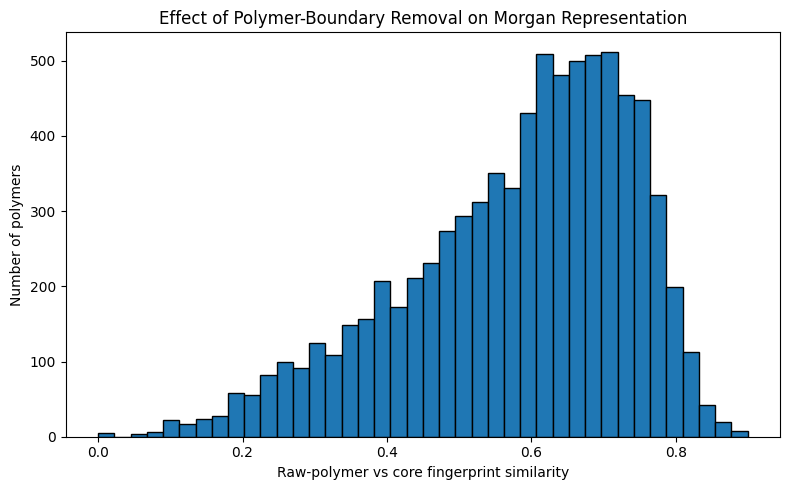

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    raw_core_similarity,
    bins=40,
    edgecolor="black"
)

plt.xlabel(
    "Raw-polymer vs core fingerprint similarity"
)

plt.ylabel(
    "Number of polymers"
)

plt.title(
    "Effect of Polymer-Boundary Removal on Morgan Representation"
)

plt.tight_layout()
plt.show()

## 7. Chemical Similarity and Polymer Neighbourhood Structure

The radius-4 count Morgan representation retains polymer connection-point information and provides substantially greater structural resolution than the simpler fingerprint alternatives examined above.

Representation quality, however, cannot be assessed only through uniqueness.

A polymer dataset may contain thousands of unique fingerprints while still being dominated by families of highly similar structures. Such neighbourhood structure is particularly important for machine-learning evaluation because random train/test splitting may place close chemical analogues on both sides of the split.

This section therefore examines:

- similarity between randomly selected polymer pairs,
- nearest-neighbour similarity,
- the presence of highly similar structural families,
- and the overall density of polymer chemical space.

These analyses characterize structural diversity but do not yet define train/test splits. Chemistry-aware generalization will be addressed explicitly in a later notebook.

In [ ]:
# ============================================================
# Native RDKit count Morgan fingerprints — radius 4
# ============================================================

count_fps_r4_rdkit = []

for smiles in atlas["SMILES"]:

    mol = Chem.MolFromSmiles(smiles)

    fp = (
        morgan_generator_r4_hashed
        .GetCountFingerprint(mol)
    )

    count_fps_r4_rdkit.append(fp)

print("RADIUS-4 COUNT FINGERPRINT OBJECTS")
print("=" * 70)

print(
    f"Fingerprints generated: "
    f"{len(count_fps_r4_rdkit):,}"
)

RADIUS-4 COUNT FINGERPRINT OBJECTS
Fingerprints generated: 7,973


In [ ]:
# ============================================================
# Random-pair chemical similarity
# ============================================================

N_RANDOM_PAIRS = 50_000

rng = np.random.default_rng(
    RANDOM_STATE
)

pair_i = rng.integers(
    0,
    len(atlas),
    size=N_RANDOM_PAIRS
)

pair_j = rng.integers(
    0,
    len(atlas),
    size=N_RANDOM_PAIRS
)

# Ensure that a polymer is not compared with itself
same_mask = pair_i == pair_j

while same_mask.any():

    pair_j[same_mask] = rng.integers(
        0,
        len(atlas),
        size=same_mask.sum()
    )

    same_mask = pair_i == pair_j

In [ ]:
random_pair_similarity = np.array([
    DataStructs.TanimotoSimilarity(
        count_fps_r4_rdkit[i],
        count_fps_r4_rdkit[j]
    )
    for i, j in zip(pair_i, pair_j)
])

print("RANDOM-PAIR POLYMER SIMILARITY")
print("=" * 70)

display(
    pd.Series(
        random_pair_similarity,
        name="Tanimoto similarity"
    )
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame()
    .round(4)
)

RANDOM-PAIR POLYMER SIMILARITY


,Tanimoto similarity
count,50000.0000
mean,0.1064
std,0.0733
min,0.0041
10%,0.0255
25%,0.0514
50%,0.0959
75%,0.1436
90%,0.1953
95%,0.2353


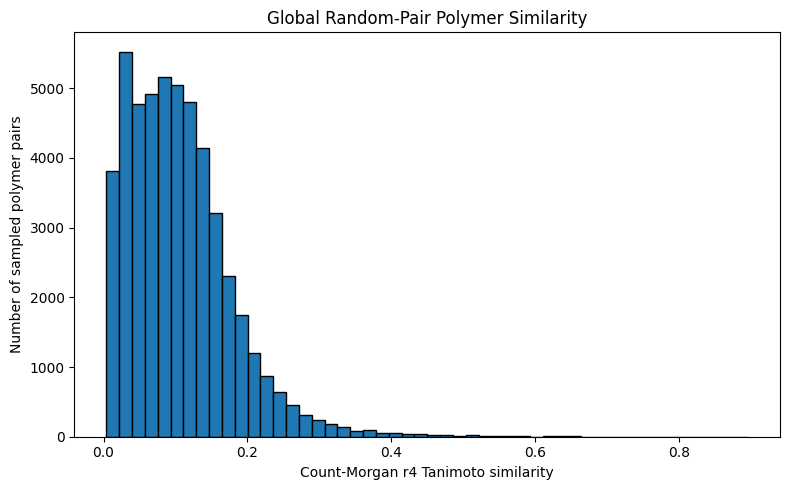

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    random_pair_similarity,
    bins=50,
    edgecolor="black"
)

plt.xlabel(
    "Count-Morgan r4 Tanimoto similarity"
)

plt.ylabel(
    "Number of sampled polymer pairs"
)

plt.title(
    "Global Random-Pair Polymer Similarity"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Nearest-neighbour similarity
# ============================================================

N_QUERY_POLYMERS = 1000

query_indices = rng.choice(
    len(atlas),
    size=N_QUERY_POLYMERS,
    replace=False
)

nearest_similarity = []
nearest_index = []

for query_idx in query_indices:

    similarities = np.array(
        DataStructs.BulkTanimotoSimilarity(
            count_fps_r4_rdkit[query_idx],
            count_fps_r4_rdkit
        )
    )

    # Remove self-similarity
    similarities[query_idx] = -1.0

    best_idx = similarities.argmax()

    nearest_similarity.append(
        similarities[best_idx]
    )

    nearest_index.append(
        best_idx
    )

nearest_similarity = np.array(
    nearest_similarity
)

nearest_index = np.array(
    nearest_index
)

In [ ]:
print("NEAREST-NEIGHBOUR POLYMER SIMILARITY")
print("=" * 70)

display(
    pd.Series(
        nearest_similarity,
        name="Nearest-neighbour similarity"
    )
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame()
    .round(4)
)

NEAREST-NEIGHBOUR POLYMER SIMILARITY


,Nearest-neighbour similarity
count,1000.0000
mean,0.6800
std,0.1706
min,0.1964
10%,0.4494
25%,0.5546
50%,0.6969
75%,0.8103
90%,0.8971
95%,0.9394


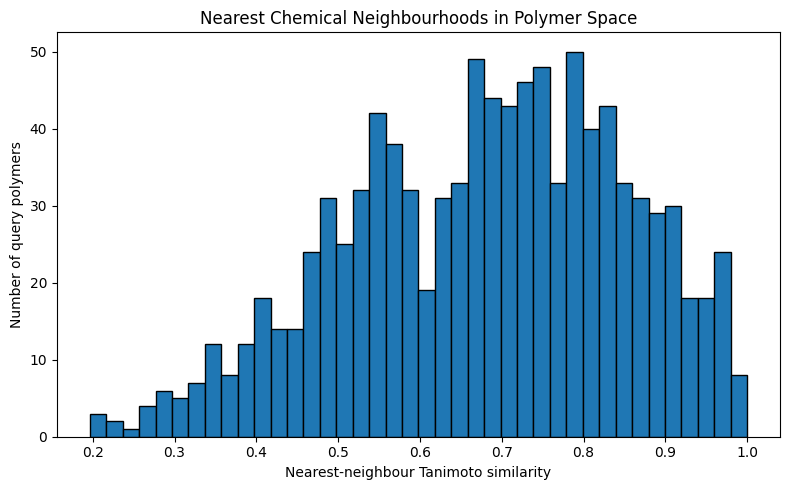

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    nearest_similarity,
    bins=40,
    edgecolor="black"
)

plt.xlabel(
    "Nearest-neighbour Tanimoto similarity"
)

plt.ylabel(
    "Number of query polymers"
)

plt.title(
    "Nearest Chemical Neighbourhoods in Polymer Space"
)

plt.tight_layout()
plt.show()

In [ ]:
nearest_neighbor_table = pd.DataFrame({
    "query_index": query_indices,
    "neighbor_index": nearest_index,
    "similarity": nearest_similarity
})

nearest_neighbor_table["query_id"] = (
    atlas.iloc[
        nearest_neighbor_table["query_index"]
    ]["id"]
    .to_numpy()
)

nearest_neighbor_table["neighbor_id"] = (
    atlas.iloc[
        nearest_neighbor_table["neighbor_index"]
    ]["id"]
    .to_numpy()
)

nearest_neighbor_table["query_SMILES"] = (
    atlas.iloc[
        nearest_neighbor_table["query_index"]
    ]["SMILES"]
    .to_numpy()
)

nearest_neighbor_table["neighbor_SMILES"] = (
    atlas.iloc[
        nearest_neighbor_table["neighbor_index"]
    ]["SMILES"]
    .to_numpy()
)

print("MOST SIMILAR NEAREST-NEIGHBOUR PAIRS")
print("=" * 70)

display(
    nearest_neighbor_table
    .sort_values(
        "similarity",
        ascending=False
    )
    .head(20)
)

MOST SIMILAR NEAREST-NEIGHBOUR PAIRS


,query_index,neighbor_index,similarity,query_id,neighbor_id,query_SMILES,neighbor_SMILES
317,1130,7657,1.000000,302309984,2066820207,*c1ccc(Oc2ccc(N3C(=O)c4ccc(Oc5ccc(Oc6ccc(Oc7cc...,*c1ccc(Oc2ccc(Oc3ccc(N4C(=O)c5ccc(Oc6ccc(Oc7cc...
169,7101,1917,1.000000,1918242337,515584536,*C(=O)Nc1ccc(Oc2ccc(NC(=O)c3ccc4c(c3)C(=O)N(c3...,*C(=O)Nc1ccc(Oc2ccc(C3(c4ccc(Oc5ccc(NC(=O)c6cc...
736,5489,5991,1.000000,1487920180,1624631059,*CC(*)(C)C(=O)OCCCCCCOc1ccc(C(=O)Oc2ccc(OCCCC)...,*CC(*)(C)C(=O)OCCCCCCOc1ccc(OC(=O)c2ccc(OCCCC)...
135,423,5541,1.000000,116488904,1504459006,*CCCCCCCCCCCCOC(=O)CCCCCCCCCCCCC(=O)O*,*CCCCCCCCCCCCCCCCOC(=O)CCCCCCCCC(=O)O*
181,5719,4673,1.000000,1551667752,1257958128,*CCCCCCCCNC(=O)CCCCCCCCCCC(=O)N*,*CCCCCCCCCNC(=O)CCCCCCCCCC(=O)N*
696,1820,7411,1.000000,491291994,2003333074,*CCCCCCCCCCCCNC(=O)CCCCCCCCCCCCCCC(=O)N*,*CCCCCCCCCCNC(=O)CCCCCCCCCCCCCCCCC(=O)N*
246,6125,4753,0.981132,1662111173,1284164313,*c1ccc(Oc2ccc(-c3nc4ccc(Oc5ccc6nc(*)c(-c7ccccc...,*c1ccc(Oc2ccc(-c3nc4cc(Oc5ccc6nc(*)c(-c7ccccc7...
272,3642,6330,0.980676,988557841,1715831147,*c1ccc(Oc2ccc(-c3nc4ccc(-c5ccc6nc(*)c(-c7ccccc...,*c1ccc(Oc2ccc(-c3nc4cc(-c5ccc6nc(*)c(-c7ccccc7...
783,2054,5461,0.978632,553763789,1481191612,*Nc1cc(C)c(Cc2ccc(CCCCCCCCCCCCCCCCCCCc3ccc(Cc4...,*Nc1cc(C)c(Cc2ccc(CCCCCCCCCCCCCCCCCCCCc3ccc(Cc...
215,5385,3373,0.977273,1462748332,924221537,*c1ccc(-c2nc3ccc(-c4ccc5nc(*)c(-c6ccccc6)nc5c4...,*c1ccc(-c2nc3cc(-c4ccc5nc(*)c(-c6ccccc6)nc5c4)...


In [ ]:
print("MOST ISOLATED QUERY POLYMERS")
print("=" * 70)

display(
    nearest_neighbor_table
    .sort_values(
        "similarity",
        ascending=True
    )
    .head(20)
)

MOST ISOLATED QUERY POLYMERS


,query_index,neighbor_index,similarity,query_id,neighbor_id,query_SMILES,neighbor_SMILES
106,967,4959,0.196364,264552260,1343284955,*Nc1cc(N*)c2cc1N(C)c1cc(C(=O)OC)cc(c1)N(C)c1cc...,*C(=O)c1cc2c(cc1Cl)C(=O)N(c1cc(C(=O)OC)cc(N3C(...
848,841,1256,0.200000,234483624,337825369,*C1CC(*)OC(O)O1,*C1CCOC1*
584,6663,3472,0.215190,1809093717,950036559,*CCP(Cl)(Cl)=Nc1ccc(N=P(*)(Cl)Cl)cc1,*N=Nc1ccc(*)cc1
531,3960,6907,0.224806,1072790069,1870206037,*Nc1c(CC(=O)O)cc2c(N*)nc(N)nc2c1C=O,*Nc1c(S(=O)(=O)O)cc2cc(S(=O)(=O)O)c(N)c(O)c2c1N*
250,4836,6976,0.232704,1308663062,1887528434,*N[C@@]12C3=CCc4ccccc4[C@]31[C@@]21[C@]2(NC)C3...,*Nc1ccccc1C1(c2ccccc2N*)CCCCC1
663,5232,4986,0.245098,1420737735,1349968586,*N[C@@H](CCCC(=O)[C@](N)(CS)C(=O)O)C(=O)[C@@](...,*NC(=O)[C@H](CCC[C@H](N)C(=O)O)N*
331,6430,6115,0.257485,1744915619,1657554335,*c1ccccc1C(=O)Oc1ccc2c(*)c3ccc(=O)cc-3oc2c1,*Oc1ccc(OC(=O)c2ccc(C(*)=O)cc2-c2ccccc2)cc1
867,6049,7595,0.261261,1640191566,2051195531,*OCCOc1cc(*)nc2ccc(C)cc12,*c1ccc2nc(*)cc(-c3ccccc3)c2c1
835,5375,3567,0.267857,1459842972,973722160,*N[C@H]1OC(N)(N*)NC1=O,*NC1=C(N)[C@@H](N*)NC(=O)N1
997,326,209,0.272727,91718962,61414691,*OC(CCC)CCC(C(*)=O)C1OCCCO1,*OC(CCC)COC(*)=O


## 8. Final Feature-Space Quality Audit

The preceding experiments identify radius-4 count Morgan fingerprints with retained polymer connection points as the strongest high-dimensional structural representation developed in this notebook.

Before the representation is exported for predictive modelling, its feature space is audited for:

- invariant features,
- extremely rare features,
- highly prevalent features,
- per-polymer feature density,
- and basic numerical validity.

This audit does not remove features solely because they are rare. Rare structural environments may represent chemically important polymer families.

Feature filtering, when required by a downstream model, will be performed within the training pipeline to avoid information leakage.

In [ ]:
# ============================================================
# Count-Morgan r4 feature utilization
# ============================================================

r4_nonzero_frequency = (
    count_fp_matrix_r4 > 0
).sum(axis=0)

r4_total_counts = (
    count_fp_matrix_r4.sum(axis=0)
)

n_unused_r4 = (
    r4_nonzero_frequency == 0
).sum()

n_universal_r4 = (
    r4_nonzero_frequency == len(atlas)
).sum()

n_very_rare_r4 = (
    r4_nonzero_frequency <= 5
).sum()

n_rare_1pct_r4 = (
    r4_nonzero_frequency
    <= 0.01 * len(atlas)
).sum()

print("COUNT-MORGAN r4 FEATURE UTILIZATION")
print("=" * 70)

print(f"Total features:                   {MORGAN_BITS:,}")
print(f"Unused features:                  {n_unused_r4:,}")
print(f"Universal features:               {n_universal_r4:,}")
print(f"Features present in <=5 polymers: {n_very_rare_r4:,}")
print(f"Features present in <=1%:         {n_rare_1pct_r4:,}")

COUNT-MORGAN r4 FEATURE UTILIZATION
Total features:                   2,048
Unused features:                  0
Universal features:               1
Features present in <=5 polymers: 0
Features present in <=1%:         340


In [ ]:
feature_usage_summary = pd.Series(
    r4_nonzero_frequency,
    name="Number of polymers containing feature"
)

print("FEATURE OCCURRENCE DISTRIBUTION")
print("=" * 70)

display(
    feature_usage_summary
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame()
    .round(2)
)

FEATURE OCCURRENCE DISTRIBUTION


,Number of polymers containing feature
count,2048.00
mean,262.36
std,490.90
min,28.00
1%,44.47
5%,60.00
10%,69.00
25%,91.00
50%,137.00
75%,238.25


In [ ]:
r4_nonzero_per_polymer = (
    count_fp_matrix_r4 > 0
).sum(axis=1)

r4_total_environment_counts = (
    count_fp_matrix_r4.sum(axis=1)
)

r4_polymer_feature_summary = pd.DataFrame({
    "nonzero_features":
        r4_nonzero_per_polymer,

    "total_environment_counts":
        r4_total_environment_counts
})

print("PER-POLYMER r4 FEATURE SUMMARY")
print("=" * 70)

display(
    r4_polymer_feature_summary
    .describe()
    .T
    .round(3)
)

PER-POLYMER r4 FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
nonzero_features,7973.0,67.391,28.790,4.0,46.0,65.0,88.0,231.0
total_environment_counts,7973.0,136.795,77.414,6.0,78.0,127.0,182.0,679.0


## 9. Representation Sets for Downstream Modelling

Three representation families are retained for controlled predictive comparison.

### Representation A — Interpretable polymer descriptors

This representation contains chemically understandable variables describing repeat-unit size, elemental composition, aromaticity, ring structure, functional-group occurrence, and polymer connection architecture.

Its primary advantage is interpretability.

### Representation B — Count Morgan radius 4

This representation contains 2048 hashed count features encoding local polymer-graph environments up to radius four while retaining wildcard polymer connection points.

It provides substantially greater structural resolution than binary fingerprints or smaller-radius alternatives.

### Representation C — Hybrid representation

The hybrid representation combines interpretable global descriptors with radius-4 count Morgan features.

This tests whether chemically meaningful global information complements high-dimensional local structural environments.

The three representations will be compared under identical modelling and validation procedures rather than assuming that the highest-dimensional representation is necessarily superior.

In [ ]:
interpretable_features = [
    # Polymer architecture
    "n_connection_points",

    # Repeat-unit size
    "n_heavy_atoms",

    # Element counts
    "n_C",
    "n_N",
    "n_O",
    "n_S",
    "n_halogen",
    "n_hetero",
    "n_aromatic",
    "n_rings",

    # Composition fractions
    "hetero_fraction",
    "aromatic_fraction",
    "carbon_fraction",
    "N_fraction",
    "O_fraction",
    "S_fraction",
    "halogen_fraction",
    "ring_density",

    # Functional-group counts
    "fg_carbonyl",
    "fg_ester",
    "fg_amide",
    "fg_ether",
    "fg_hydroxyl",
    "fg_nitrile",
    "fg_sulfone",
    "fg_c_c_double_bond",
    "fg_c_f_bond",

    # Functional-group densities
    "density_carbonyl",
    "density_ester",
    "density_amide",
    "density_ether",
    "density_hydroxyl",
    "density_nitrile",
    "density_sulfone",
    "density_c_c_double_bond",
    "density_c_f_bond"
]

print("FINAL INTERPRETABLE REPRESENTATION")
print("=" * 70)

print(
    f"Number of interpretable features: "
    f"{len(interpretable_features)}"
)

for feature in interpretable_features:
    print(f"  - {feature}")

FINAL INTERPRETABLE REPRESENTATION
Number of interpretable features: 36
  - n_connection_points
  - n_heavy_atoms
  - n_C
  - n_N
  - n_O
  - n_S
  - n_halogen
  - n_hetero
  - n_aromatic
  - n_rings
  - hetero_fraction
  - aromatic_fraction
  - carbon_fraction
  - N_fraction
  - O_fraction
  - S_fraction
  - halogen_fraction
  - ring_density
  - fg_carbonyl
  - fg_ester
  - fg_amide
  - fg_ether
  - fg_hydroxyl
  - fg_nitrile
  - fg_sulfone
  - fg_c_c_double_bond
  - fg_c_f_bond
  - density_carbonyl
  - density_ester
  - density_amide
  - density_ether
  - density_hydroxyl
  - density_nitrile
  - density_sulfone
  - density_c_c_double_bond
  - density_c_f_bond


In [ ]:
X_interpretable = (
    atlas[
        interpretable_features
    ]
    .to_numpy(dtype=np.float32)
)

X_morgan_r4 = (
    count_fp_matrix_r4
    .astype(np.float32)
)

X_hybrid = np.hstack([
    X_interpretable,
    X_morgan_r4
])

print("FINAL REPRESENTATION MATRICES")
print("=" * 70)

print(
    f"Interpretable: {X_interpretable.shape}"
)

print(
    f"Morgan r4:    {X_morgan_r4.shape}"
)

print(
    f"Hybrid:       {X_hybrid.shape}"
)

FINAL REPRESENTATION MATRICES
Interpretable: (7973, 36)
Morgan r4:    (7973, 2048)
Hybrid:       (7973, 2084)


In [ ]:
representation_integrity = pd.DataFrame({
    "Interpretable": [
        np.isnan(X_interpretable).sum(),
        np.isinf(X_interpretable).sum()
    ],

    "Morgan_r4": [
        np.isnan(X_morgan_r4).sum(),
        np.isinf(X_morgan_r4).sum()
    ],

    "Hybrid": [
        np.isnan(X_hybrid).sum(),
        np.isinf(X_hybrid).sum()
    ]
},
index=[
    "Missing values",
    "Infinite values"
])

print("REPRESENTATION INTEGRITY")
print("=" * 70)

display(representation_integrity)

REPRESENTATION INTEGRITY


,Interpretable,Morgan_r4,Hybrid
Missing values,0,0,0
Infinite values,0,0,0


## 10. Exporting Modelling-Ready Representations

The finalized structural representations are exported separately from the property targets.

This separation prevents structural feature construction from becoming entangled with target-specific modelling decisions and allows subsequent notebooks to reconstruct each property dataset reproducibly.

The exported matrices preserve row order relative to the accompanying metadata table.

In [ ]:
output_dir = Path(
    "polymer_atlas_notebook02_outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
np.save(
    output_dir / "X_interpretable.npy",
    X_interpretable
)

np.save(
    output_dir / "X_morgan_count_r4.npy",
    X_morgan_r4
)

np.save(
    output_dir / "X_hybrid.npy",
    X_hybrid
)

In [ ]:
pd.Series(
    interpretable_features,
    name="feature"
).to_csv(
    output_dir
    / "interpretable_feature_names.csv",
    index=False
)

In [ ]:
model_metadata = atlas[
    [
        "id",
        "SMILES",
        "canonical_smiles",
        "Tg",
        "FFV",
        "Tc",
        "Density",
        "Rg"
    ]
].copy()

model_metadata.to_csv(
    output_dir
    / "polymer_model_metadata.csv",
    index=False
)

In [ ]:
representation_comparison_extended.to_csv(
    output_dir
    / "morgan_representation_comparison.csv"
)

boundary_information_comparison.to_csv(
    output_dir
    / "boundary_information_comparison.csv"
)

nearest_neighbor_table.to_csv(
    output_dir
    / "nearest_neighbor_sample.csv",
    index=False
)

In [ ]:
X_interpretable_check = np.load(
    output_dir / "X_interpretable.npy"
)

X_morgan_check = np.load(
    output_dir / "X_morgan_count_r4.npy"
)

X_hybrid_check = np.load(
    output_dir / "X_hybrid.npy"
)

metadata_check = pd.read_csv(
    output_dir
    / "polymer_model_metadata.csv"
)

print("NOTEBOOK 02 EXPORT VERIFICATION")
print("=" * 70)

print(
    "Interpretable shape:",
    X_interpretable_check.shape
)

print(
    "Morgan shape:",
    X_morgan_check.shape
)

print(
    "Hybrid shape:",
    X_hybrid_check.shape
)

print(
    "Metadata shape:",
    metadata_check.shape
)

print(
    "IDs preserved:",
    metadata_check["id"].nunique()
    == atlas["id"].nunique()
)

print(
    "Row count preserved:",
    len(metadata_check) == len(atlas)
)

NOTEBOOK 02 EXPORT VERIFICATION
Interpretable shape: (7973, 36)
Morgan shape: (7973, 2048)
Hybrid shape: (7973, 2084)
Metadata shape: (7973, 8)
IDs preserved: True
Row count preserved: True


# 11. Notebook 02 — Key Findings and Representation Decisions

Notebook 02 investigated how polymer repeat-unit chemistry should be represented for downstream machine-learning analysis.

Rather than selecting a fingerprint convention in advance, alternative polymer representations were evaluated through controlled structural-resolution experiments.

## Polymer connection-point representation

The original polymer SMILES contain wildcard atoms (`*`) that encode continuation of the repeat unit into the macromolecular chain.

Removing these connection points was found to be non-neutral.

Of 7,973 original polymer structures:

- 7,956 could be converted into sanitized valence-completed finite cores,
- 17 transformations failed,
- and only 7,849 unique finite cores remained.

The finite-core transformation produced 98 representation-collision groups involving 285 original polymer records.

Several collision groups contained different reported values for the same target property, demonstrating that boundary removal can collapse records that remain distinct in the original polymer representation.

A controlled radius-4 count-Morgan comparison on the same 7,956 valid records further confirmed the importance of polymer-boundary information.

The wildcard-containing polymer representation produced:

- 7,926 unique fingerprints,
- 21 collision groups,
- and 51 records involved in collisions.

The corresponding boundary-removed representation produced:

- 7,825 unique fingerprints,
- 118 collision groups,
- and 249 records involved in collisions.

Boundary removal therefore eliminated 101 unique structural representations and introduced 198 additional records into fingerprint-collision groups.

The median similarity between the original and boundary-removed radius-4 count fingerprints was approximately 0.61, confirming that wildcard removal alters a substantial fraction of the represented local chemical environments.

The wildcard-containing polymer graph is therefore retained as the primary structural representation.

## Binary versus count Morgan fingerprints

A radius-2, 2048-bit binary Morgan fingerprint was initially evaluated.

Although every polymer could be represented successfully, the binary representation produced:

- 6,840 unique fingerprints,
- 519 collision groups,
- 1,652 records involved in collisions,
- and a largest collision group containing 66 polymers.

Inspection of large collision groups demonstrated that many consisted of homologous structures differing primarily in repeat-unit size or motif repetition.

Binary fingerprints encode whether a local environment is present but not how many times it occurs.

Replacing binary fingerprints with count fingerprints while keeping radius and dimensionality fixed substantially improved structural resolution:

- unique fingerprints increased from 6,840 to 7,835,
- collision groups decreased from 519 to 103,
- records involved in collisions decreased from 1,652 to 241,
- and the largest collision group decreased from 66 to 7.

This demonstrates that local-environment multiplicity is particularly important in polymer representation.

## Effect of Morgan radius

Residual count-fingerprint collisions were subsequently investigated by increasing the structural neighbourhood radius.

The progression was:

| Representation | Unique fingerprints | Collision groups | Records in collisions | Largest group |
| --- | ---: | ---: | ---: | ---: |
| Binary Morgan r2 | 6,840 | 519 | 1,652 | 66 |
| Count Morgan r2 | 7,835 | 103 | 241 | 7 |
| Count Morgan r3 | 7,908 | 50 | 115 | 5 |
| Count Morgan r4 | 7,943 | 21 | 51 | 5 |

The largest gain arose from retaining motif multiplicity. Increasing radius subsequently recovered additional information concerning longer-range structural arrangement.

Radius 4 resolved 35 additional polymer representations relative to radius 3 and removed 64 records from collision groups.

## Hashing diagnostic

The fixed 2048-dimensional radius-3 representation was compared with an unhashed sparse radius-3 count representation.

Both produced exactly:

- 7,908 unique fingerprints,
- 50 collision groups,
- 115 records involved in collisions,
- and a largest collision group of 5.

The same test at radius 4 produced identical hashed and unhashed record-level results:

- 7,943 unique fingerprints,
- 21 collision groups,
- 51 records involved in collisions,
- and a largest collision group of 5.

Therefore, fixed 2048-dimensional hashing does not introduce additional record-level representation collisions in the present radius-4 dataset.

Increasing the fingerprint width to 4096 is consequently not justified by the current evidence.

## Polymer chemical-neighbourhood structure

Random-pair and nearest-neighbour similarity analyses revealed two complementary characteristics of the dataset.

For 50,000 randomly sampled polymer pairs:

- mean similarity was approximately 0.106,
- median similarity was approximately 0.096,
- 95% of pairs were below approximately 0.235.

The dataset is therefore globally chemically diverse.

However, among 1,000 sampled query polymers:

- mean nearest-neighbour similarity was approximately 0.680,
- median nearest-neighbour similarity was approximately 0.697,
- the 90th percentile was approximately 0.897,
- and the 95th percentile was approximately 0.939.

Thus, broad global diversity coexists with dense local families of structurally related polymers.

This observation motivates chemistry-aware validation in later notebooks because random train/test splitting may place close chemical analogues on opposite sides of the split and thereby overestimate generalization to genuinely novel polymer chemistry.

## Final representation families

Three structural representations are retained for downstream predictive comparison.

### Representation A — Interpretable polymer descriptors

36 chemically interpretable variables describing:

- polymer connection architecture,
- repeat-unit size,
- elemental composition,
- aromaticity,
- ring structure,
- functional-group counts,
- and size-normalized functional-group densities.

### Representation B — Count Morgan radius 4

A 2048-dimensional count fingerprint with:

- radius = 4,
- chirality retained,
- polymer wildcard connection points retained,
- and local-environment multiplicity preserved.

This is the primary high-dimensional structural representation selected by Notebook 02.

### Representation C — Hybrid representation

The 36 interpretable descriptors are concatenated with the 2048 radius-4 count-Morgan features to create a 2084-dimensional representation.

The hybrid representation tests whether chemically interpretable global information complements high-dimensional local structural environments.

## Final modelling principle

Notebook 02 does not assume that the most structurally detailed representation will necessarily produce the best predictive model.

Notebook 03 will compare the interpretable, Morgan, and hybrid representations under identical modelling and validation conditions.

The selected representation will therefore be judged by predictive accuracy, robustness, generalization, and scientific interpretability rather than dimensionality alone.

In [ ]:
# ============================================================
# Save complete feature-name manifests
# ============================================================

morgan_feature_names = [
    f"morgan_r4_{i}"
    for i in range(MORGAN_BITS)
]

hybrid_feature_names = (
    interpretable_features
    + morgan_feature_names
)

pd.Series(
    morgan_feature_names,
    name="feature"
).to_csv(
    output_dir / "morgan_r4_feature_names.csv",
    index=False
)

pd.Series(
    hybrid_feature_names,
    name="feature"
).to_csv(
    output_dir / "hybrid_feature_names.csv",
    index=False
)

print("Feature-name manifests saved.")

Feature-name manifests saved.


In [ ]:
import json

representation_config = {
    "morgan_type": "count",
    "radius": 4,
    "fp_size": 2048,
    "include_chirality": True,
    "polymer_wildcards_retained": True,
    "n_polymers": int(len(atlas)),
    "n_interpretable_features": int(
        X_interpretable.shape[1]
    ),
    "n_morgan_features": int(
        X_morgan_r4.shape[1]
    ),
    "n_hybrid_features": int(
        X_hybrid.shape[1]
    ),
    "random_state": int(RANDOM_STATE)
}

with open(
    output_dir / "representation_config.json",
    "w"
) as f:
    json.dump(
        representation_config,
        f,
        indent=2
    )

print("Representation configuration saved.")

Representation configuration saved.


In [ ]:
import shutil

zip_path = shutil.make_archive(
    "polymer_atlas_notebook02_outputs",
    "zip",
    root_dir=str(output_dir)
)

print(
    f"Notebook 02 output archive created:\n"
    f"{zip_path}"
)

Notebook 02 output archive created:
/content/polymer_atlas_notebook02_outputs.zip


In [ ]:
from google.colab import files

files.download(
    "polymer_atlas_notebook02_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>